# Data Science - Emmanuel Maqueda & Jesed Renteria

In [85]:
import json
import requests
import pandas as pd
from sklearn.decomposition import PCA
from pandas import DataFrame
from pprint import pprint
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import KBinsDiscretizer
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

#Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GridSearchCV
import seaborn as sns

# Import real time to make a for loop to acquire daily historical weather data
from datetime import datetime, timedelta

In [87]:
#https://openweathermap.org/forecast5
#We will use this dataset for now until they accept my request to access the past year's weather data

In [89]:
# Gathers current weather data in Golden, Colorado
#lat = 39.55
#lon = -105.7821
start_dt = 1583248626 # March 3, 2020
end_dt = 1741015026 # March 3, 2025

# Coords for Aurora, Colorado:  Latitude: 39.729432,   Longitude: -104.831919
co_lat = 39.729432
co_lon = -104.831919
# Coords for Trenton, New Jersey:  Latitude: 40.220179,   Longitude: -74.764229
nj_lat = 40.220179
nj_lon = -74.764229
# Coords for Hallassee, Florida:  Latitude: 30.438183,   Longitude: -84.280623
fl_lat = 30.438183
fl_lon = -84.280623
# Coords for Dallas, Texas:  Latitude: 32.776664,   Longitude: -96.796988
tx_lat = 32.776664
tx_lon = -96.796988
# Coords for Lansing, Michigan:  Latitude: 42.733599,   Longitude: -84.553866
mi_lat = 42.733599
mi_lon = -84.553866
# Coords for Los Angeles, California:  Latitude: 34.054908,   Longitude: -118.242643
ca_lat = 34.054908
ca_lon = -118.242643
#start_date = datetime(2020, 3, 3)  # Start from March 10, 2020
#end_date = datetime(2025, 3, 3)  # Up to March 10, 2025
#start = int(start_date.timestamp())
#end = int(end_date.timestamp())
units = "imperial"
api_key = "86d8d79c88a57454f65c2d425cd5cbba"
#url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&units={units}&appid={api_key}"
#url2 = f"https://api.openweathermap.org/data/2.5/weather?q={city_name},{state_code},{country_code}&units={units}&appid={api_key}"
#url3 = f"https://history.openweathermap.org/data/2.5/history/city?lat={co_lat}&lon={co_lon}&type=hour&start={start}&end={end}&units={units}&appid={api_key}"
#dt1 = 1586468027


In [91]:
#change the lats and lons for each one.
#url4 =f"https://api.openweathermap.org/data/2.5/forecast?lat={ca_lat}&lon={ca_lon}&units={units}&appid={api_key}"
#response = requests.get(url4)
#response = json.loads(response.text)
#response

In [92]:
# The combined list of all our weather data
combined_weather_data = []
#Since almost all datasets will have some null values, it is best to impute them with 0.

In [94]:
dfCA0 = pd.read_csv("California 2020-34.06N118.23W99m.csv")
dfCA1 = pd.read_csv("California 2021-34.06N118.23W99m.csv")
dfCA2 = pd.read_csv("California 2022-34.06N118.23W99m.csv")
dfCA3 = pd.read_csv("California 2023-34.06N118.23W99m.csv")
dfCA4 = pd.read_csv("California 2024-34.06N118.23W99m.csv")
dfCA5 = pd.read_csv("California 2025-34.06N118.23W99m.csv")

dfCAAll = pd.concat([dfCA0,dfCA1,dfCA2,dfCA3,dfCA4,dfCA5], ignore_index=True)
dfCAAll.fillna(0, inplace=True)

In [96]:
dfCO0 = pd.read_csv("Colorado 2020-39.73N104.84W1648m.csv")
dfCO1 = pd.read_csv("Colorado 2021-39.73N104.84W1648m.csv")
dfCO2 = pd.read_csv("Colorado 2022-39.73N104.84W1648m.csv")
dfCO3 = pd.read_csv("Colorado 2023-39.73N104.84W1648m.csv")
dfCO4 = pd.read_csv("Colorado 2024-39.73N104.84W1648m.csv")
dfCO5 = pd.read_csv("Colorado 2025-39.73N104.84W1648m.csv")

dfCOAll = pd.concat([dfCO0,dfCO1,dfCO2,dfCO3,dfCO4,dfCO5], ignore_index=True)
dfCOAll.fillna(0, inplace=True)

In [97]:
dfFL0 = pd.read_csv("Florida 2020-30.44N84.29W69m.csv")
dfFL1 = pd.read_csv("Florida 2021-30.44N84.29W69m.csv")
dfFL2 = pd.read_csv("Florida 2022-30.44N84.29W69m.csv")
dfFL3 = pd.read_csv("Florida 2023-30.44N84.29W69m.csv")
dfFL4 = pd.read_csv("Florida 2024-30.44N84.29W69m.csv")
dfFL5 = pd.read_csv("Florida 2025-30.44N84.29W69m.csv")

dfFLAll = pd.concat([dfFL0,dfFL1,dfFL2,dfFL3,dfFL4,dfFL5], ignore_index=True)
dfFLAll.info()
dfFLAll.fillna(0, inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45960 entries, 0 to 45959
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   time                            45960 non-null  object 
 1   temperature_2m (°F)             45960 non-null  float64
 2   relative_humidity_2m (%)        45960 non-null  int64  
 3   dew_point_2m (°F)               45960 non-null  float64
 4   precipitation_probability (%)   4151 non-null   float64
 5   precipitation (inch)            45960 non-null  float64
 6   rain (inch)                     45960 non-null  float64
 7   showers (inch)                  45960 non-null  float64
 8   snowfall (inch)                 45960 non-null  float64
 9   surface_pressure (hPa)          45960 non-null  float64
 10  snow_depth (ft)                 45960 non-null  float64
 11  visibility (ft)                 45960 non-null  float64
 12  cloud_cover (%)                 

In [99]:
dfMI0 = pd.read_csv("Michigan 2020-42.74N84.57W262m.csv")
dfMI1 = pd.read_csv("Michigan 2021-42.74N84.57W262m.csv")
dfMI2 = pd.read_csv("Michigan 2022-42.74N84.57W262m.csv")
dfMI3 = pd.read_csv("Michigan 2023-42.74N84.57W262m.csv")
dfMI4 = pd.read_csv("Michigan 2024-42.74N84.57W262m.csv")
dfMI5 = pd.read_csv("Michigan 2025-42.74N84.57W262m.csv")

dfMIAll = pd.concat([dfMI0,dfMI1,dfMI2,dfMI3,dfMI4,dfMI5], ignore_index=True)
dfMIAll.fillna(0, inplace=True)

In [100]:
dfNJ0 = pd.read_csv("New Jersey 2020-40.22N74.78W18m.csv")
dfNJ1 = pd.read_csv("New Jersey 2021-40.22N74.78W18m.csv")
dfNJ2 = pd.read_csv("New Jersey 2022-40.22N74.78W18m.csv")
dfNJ3 = pd.read_csv("New Jersey 2023-40.22N74.78W18m.csv")
dfNJ4 = pd.read_csv("New Jersey 2024-40.22N74.78W18m.csv")
dfNJ5 = pd.read_csv("New Jersey 2025-40.22N74.78W18m.csv")

dfNJAll = pd.concat([dfNJ0,dfNJ1,dfNJ2,dfNJ3,dfNJ4,dfNJ5], ignore_index=True)
dfNJAll.fillna(0, inplace=True)

In [101]:
dfTX0 = pd.read_csv("Texas 2020-32.78N96.80W137m.csv")
dfTX1 = pd.read_csv("Texas 2021-32.78N96.80W137m.csv")
dfTX2 = pd.read_csv("Texas 2022-32.78N96.80W137m.csv")
dfTX3 = pd.read_csv("Texas 2023-32.78N96.80W137m.csv")
dfTX4 = pd.read_csv("Texas 2024-32.78N96.80W137m.csv")
dfTX5 = pd.read_csv("Texas 2025-32.78N96.80W137m.csv")

dfTXAll = pd.concat([dfTX0,dfTX1,dfTX2,dfTX3,dfTX4,dfTX5], ignore_index=True)
dfTXAll.fillna(0, inplace=True)

In [103]:
# Now all that the cleaning is done, we can just call these files 
dfCAAll.to_csv("California 2020-2025 cleaned.csv", index=False)
dfCOAll.to_csv("Colorado 2020-2025 cleaned.csv", index=False)
dfFLAll.to_csv("Florida 2020-2025 cleaned.csv", index=False)
dfMIAll.to_csv("Michigan 2020-2025 cleaned.csv", index=False)
dfNJAll.to_csv("New Jersey 2020-2025 cleaned.csv", index=False)
dfTXAll.to_csv("Texas 2020-2025 cleaned.csv", index=False)

In [104]:
combined_weather = pd.concat([dfCAAll, dfCOAll, dfFLAll, dfMIAll, dfNJAll, dfTXAll], ignore_index=True)


In [106]:
#extracts data from certain columns
#curr_weather_data = []
#for item in response['list']:
#    curr_weather_data.append({
#        'dt': item['dt'],
#        'dt_txt': item['dt_txt'],
#        'temp': item['main']['temp'],
#        'feels_like': item['main']['feels_like'],
#        'temp_min': item['main']['temp_min'],
#        'temp_max': item['main']['temp_max'],
#        'pressure': item['main']['pressure'],
#        'humidity': item['main']['humidity'],
#        'sea_level' : item['main']['sea_level'],
#        'grnd_level' : item['main']['grnd_level'],
#        'visibility' : item['visibility'],
#        'weather' : item['weather'][0]['main'],
#        'weather_description': item['weather'][0]['description'],
#        'wind_speed': item['wind']['speed'],
#        'wind_deg': item['wind']['deg'],
#        'wind_gust' : item['wind']['gust']
#    })
#print(co_city_data["main"])
#curr_weather = pd.DataFrame(curr_weather_data)
#Ignore this

In [107]:
combined_weather.describe()

,temperature_2m (°F),relative_humidity_2m (%),dew_point_2m (°F),precipitation_probability (%),precipitation (inch),rain (inch),showers (inch),snowfall (inch),surface_pressure (hPa),snow_depth (ft),...,wind_speed_80m (mp/h),wind_direction_10m (°),wind_direction_80m (°),wind_gusts_10m (mp/h),temperature_80m (°F),soil_temperature_6cm (°F),soil_temperature_0cm (°F),soil_moisture_0_to_1cm (m³/m³),soil_moisture_1_to_3cm (m³/m³),evapotranspiration (inch)
count,275760.000000,275760.000000,275760.000000,275760.000000,275760.000000,275760.000000,275760.0,275760.000000,275760.000000,275760.000000,...,275760.000000,275760.000000,275760.000000,275760.000000,275760.000000,275760.000000,275760.00000,275760.000000,275760.000000,275760.000000
mean,59.401618,64.149677,45.120569,0.360437,0.003163,0.003005,0.0,0.001134,974.153495,0.009740,...,10.274903,182.954348,187.249786,11.959757,45.759915,26.469554,26.49685,0.096624,0.100138,0.000003
std,18.504601,22.612488,19.037178,4.199334,0.051775,0.051662,0.0,0.017779,64.106714,0.068674,...,6.021877,97.548467,95.734370,7.600518,29.526304,31.466995,32.16433,0.122030,0.123431,0.000065
min,-14.300000,1.000000,-42.000000,0.000000,0.000000,0.000000,0.0,0.000000,806.300000,0.000000,...,0.000000,1.000000,0.000000,0.000000,-14.100000,0.000000,-5.90000,0.000000,0.000000,0.000000
25%,46.700000,47.000000,30.500000,0.000000,0.000000,0.000000,0.0,0.000000,984.500000,0.000000,...,5.600000,103.000000,112.000000,6.300000,20.900000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,61.300000,67.000000,47.300000,0.000000,0.000000,0.000000,0.0,0.000000,1001.000000,0.000000,...,9.500000,185.000000,192.000000,10.300000,55.100000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,73.200000,84.000000,60.800000,0.000000,0.000000,0.000000,0.0,0.000000,1009.000000,0.000000,...,14.000000,261.000000,262.000000,15.700000,69.100000,56.800000,56.00000,0.202000,0.208000,0.000000
max,112.800000,100.000000,84.200000,100.000000,6.350000,6.350000,0.0,1.378000,1046.100000,1.509000,...,63.100000,360.000000,360.000000,65.100000,106.200000,112.300000,129.00000,0.507000,0.507000,0.004000


In [109]:
combined_weather.to_csv("All 6 locations cleaned.csv", index=False)

In [112]:
combined_weather.info()
# time for this one won't be entirely useful since this dataset is all hourly.
num_weather = combined_weather.drop(columns = ["time"])
num_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275760 entries, 0 to 275759
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   time                            275760 non-null  object 
 1   temperature_2m (°F)             275760 non-null  float64
 2   relative_humidity_2m (%)        275760 non-null  int64  
 3   dew_point_2m (°F)               275760 non-null  float64
 4   precipitation_probability (%)   275760 non-null  float64
 5   precipitation (inch)            275760 non-null  float64
 6   rain (inch)                     275760 non-null  float64
 7   showers (inch)                  275760 non-null  float64
 8   snowfall (inch)                 275760 non-null  float64
 9   surface_pressure (hPa)          275760 non-null  float64
 10  snow_depth (ft)                 275760 non-null  float64
 11  visibility (ft)                 275760 non-null  float64
 12  cloud_cover (%) 

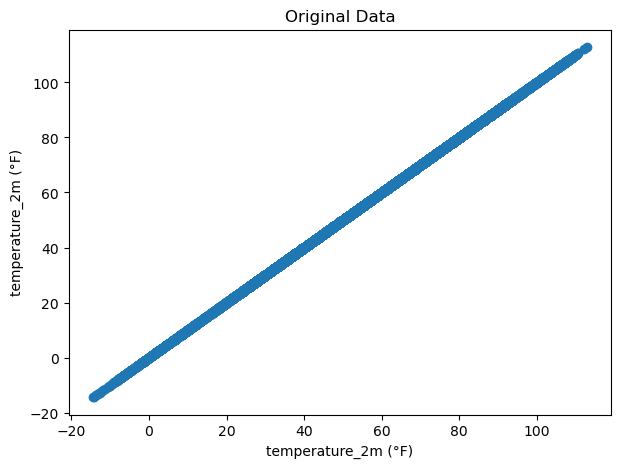

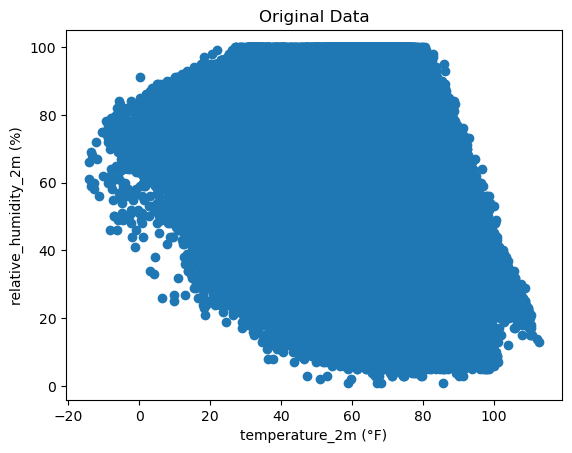

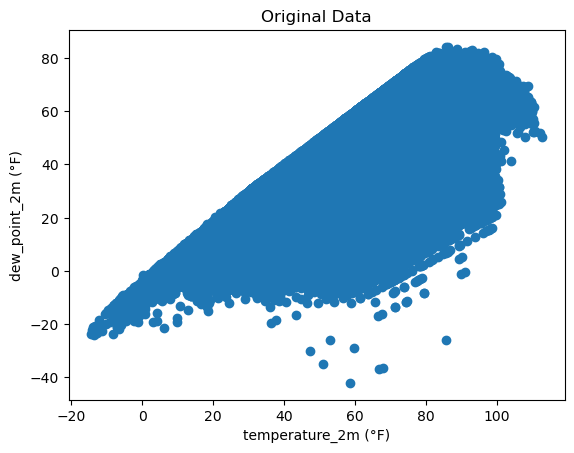

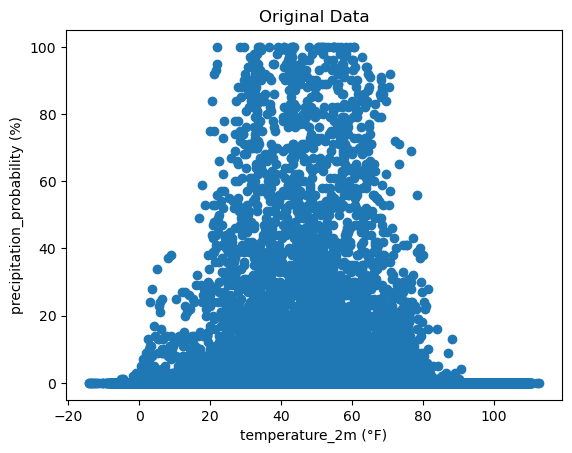

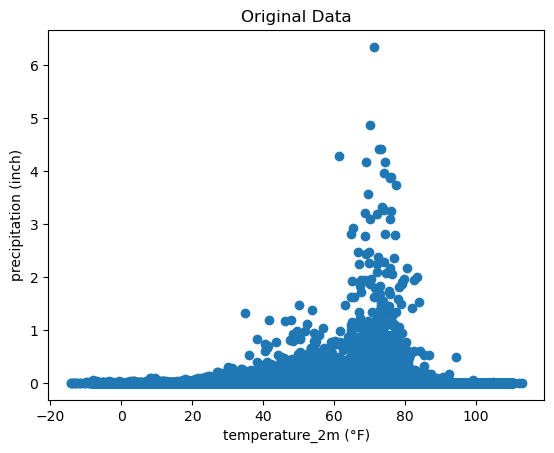

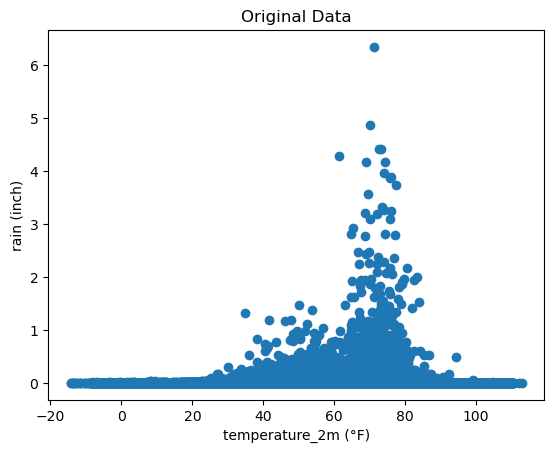

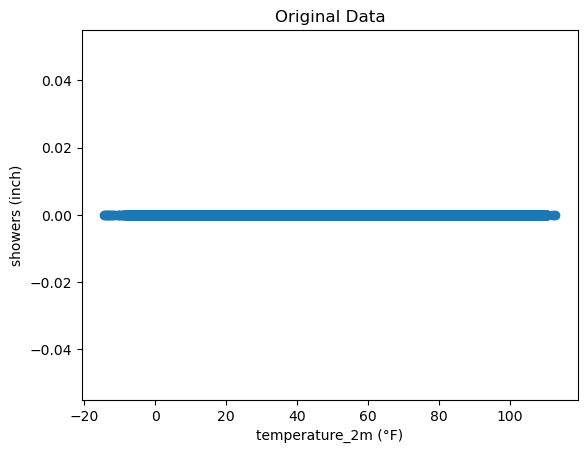

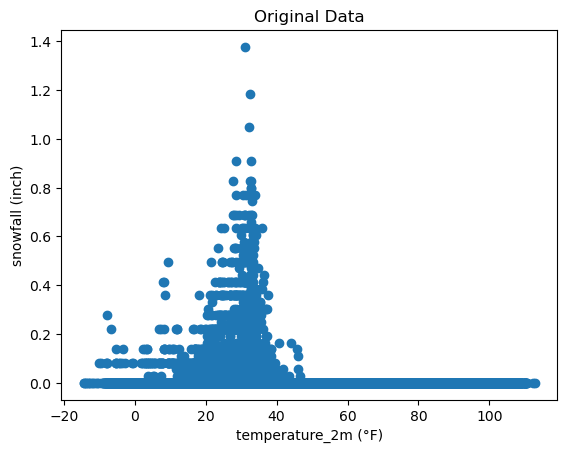

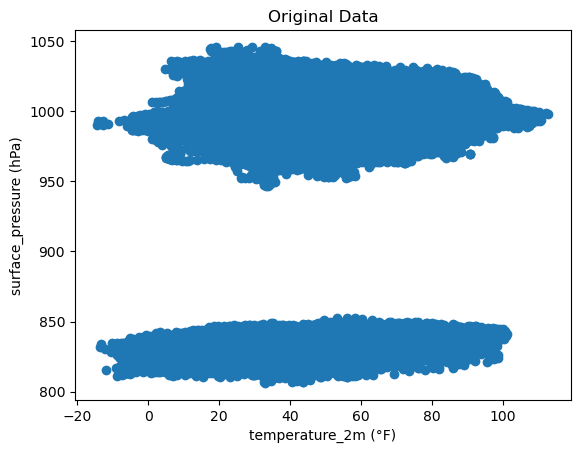

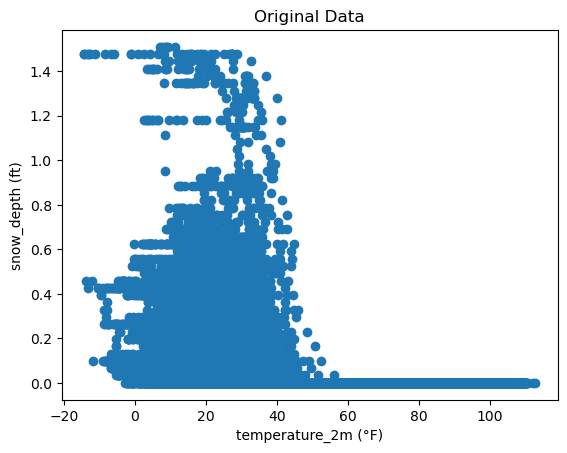

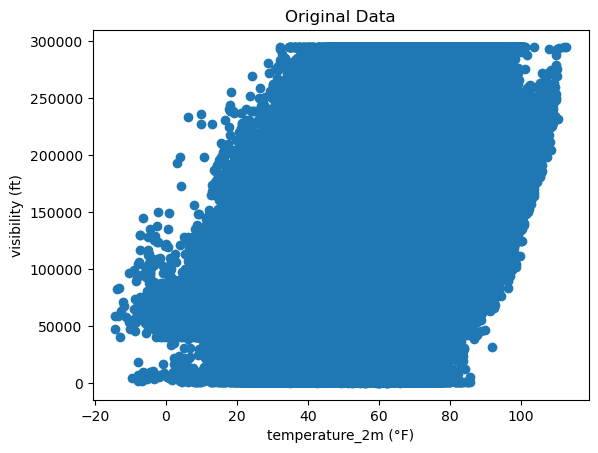

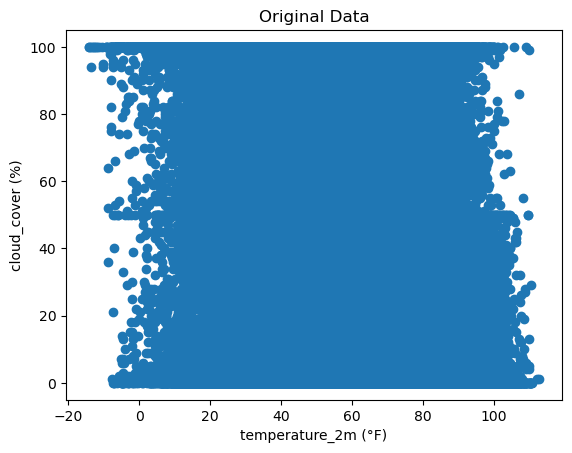

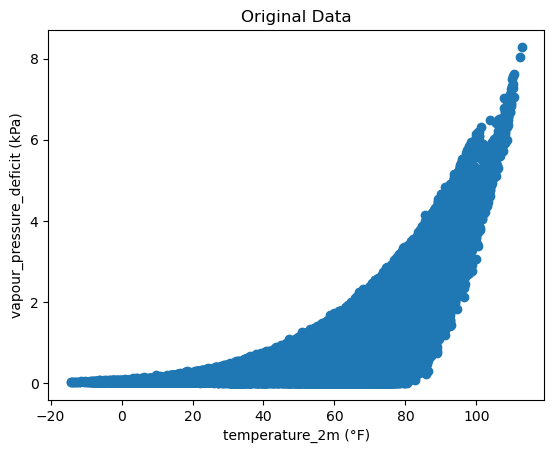

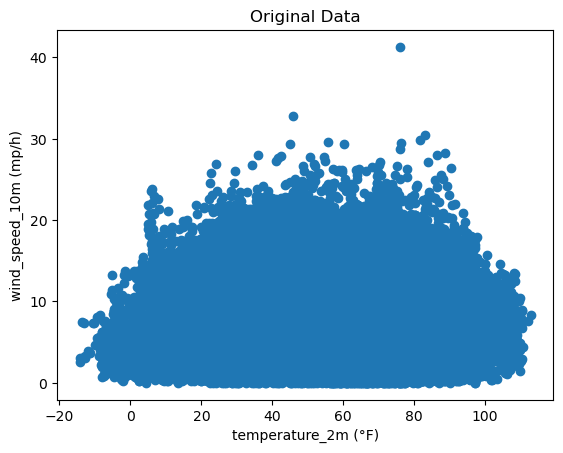

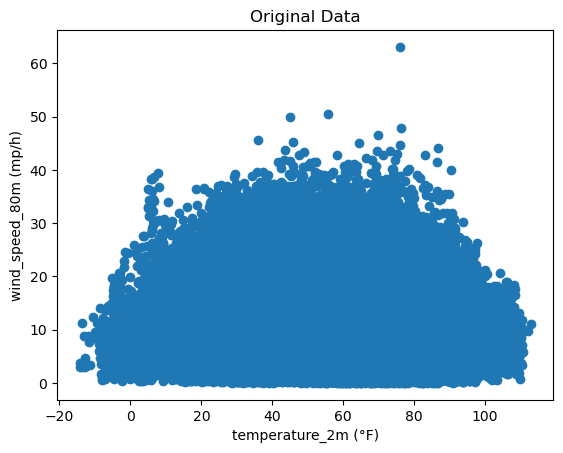

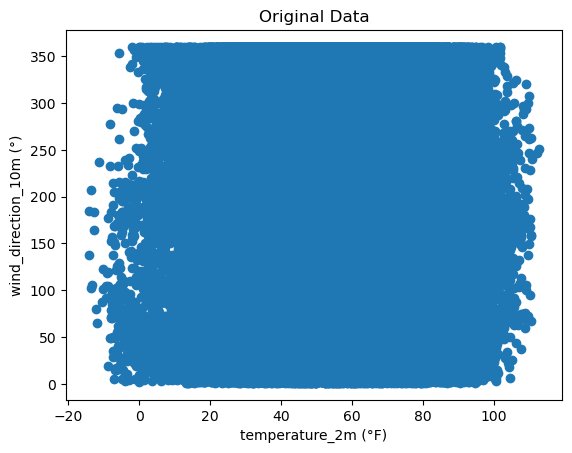

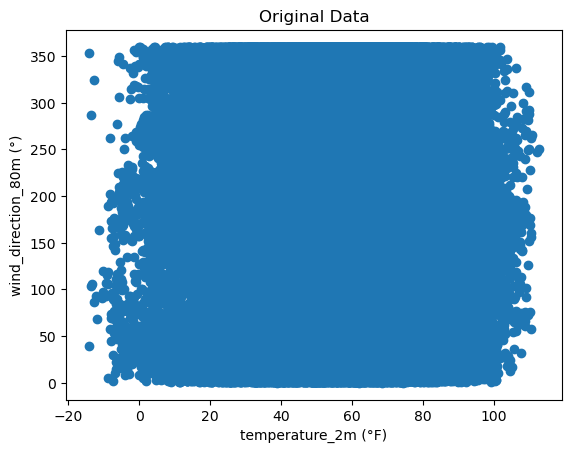

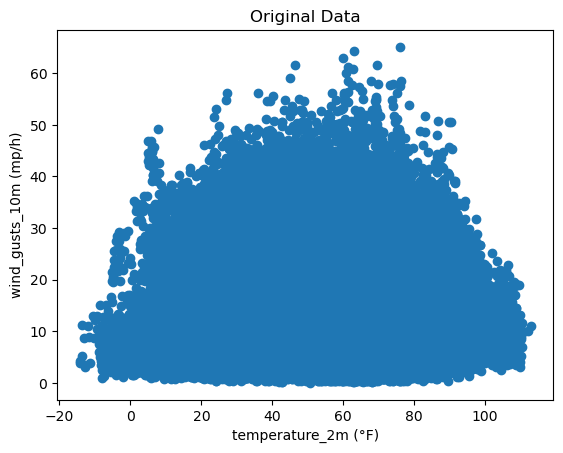

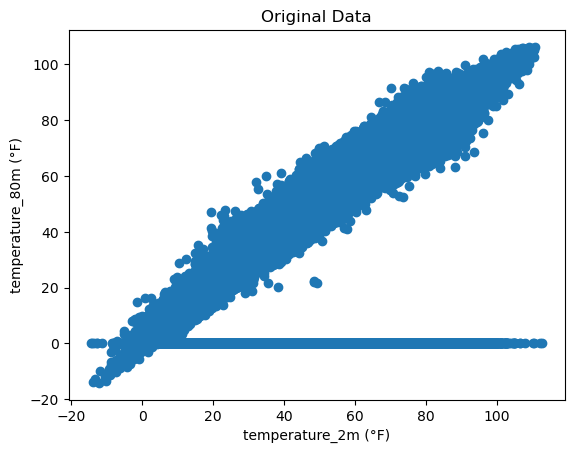

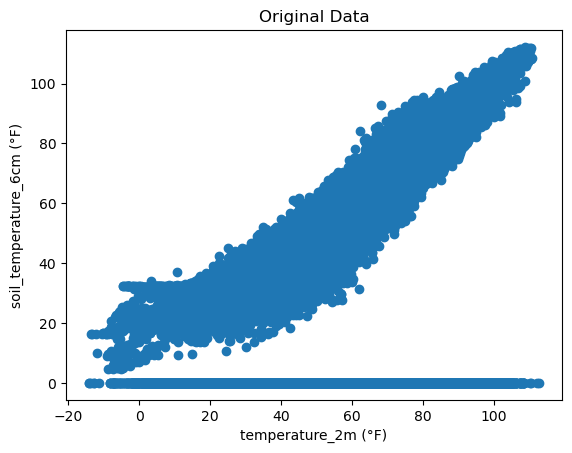

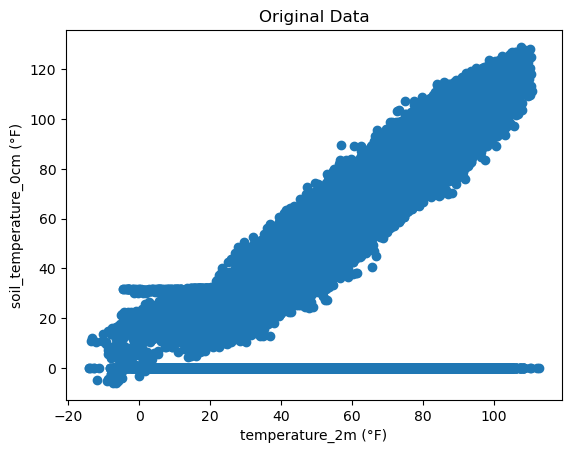

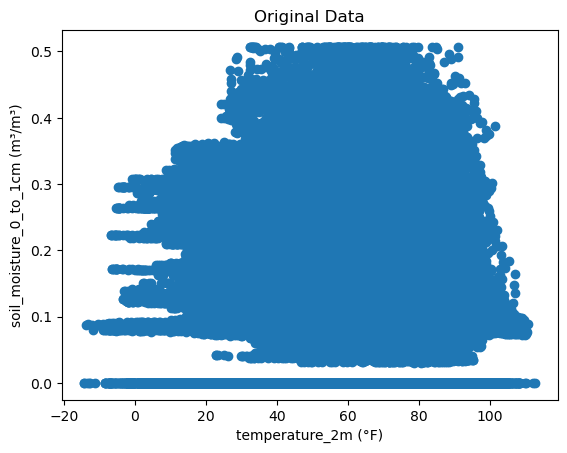

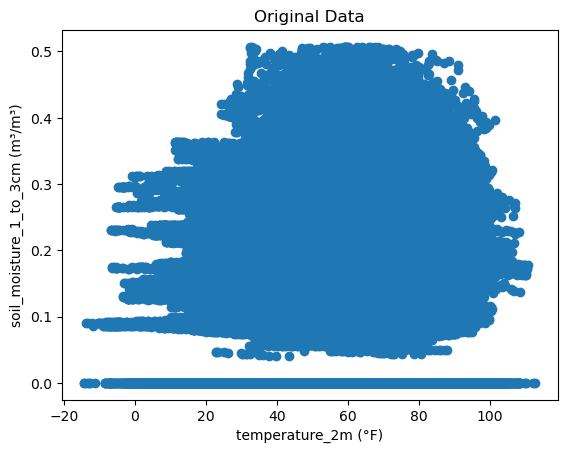

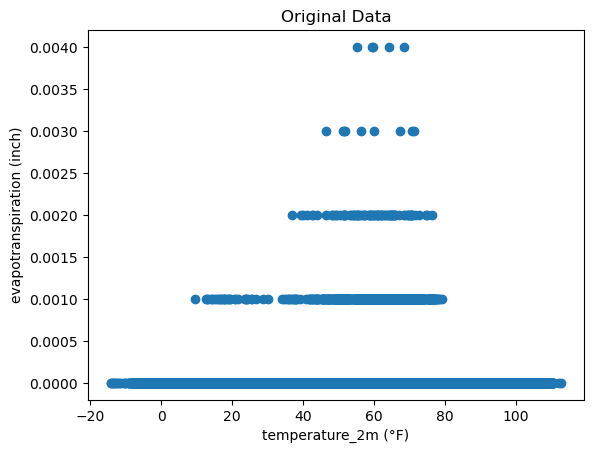

In [113]:
#curr_weather.info()

#Use Scatter Plots, bar charts, correlation matrix, df.describe() for EDA
# temperature_2m (°F) is our target variable

# A for loop that does a scatterplot to explore the relationship between temp and the other creature features
num_columns = combined_weather.select_dtypes(include=np.number)
plt.figure(figsize=(7,5))
for column in num_columns:
    #print(column)
    plt.scatter(combined_weather["temperature_2m (°F)"], combined_weather[column])
    plt.title('Original Data')
    plt.ylabel(f"{column}")
    plt.xlabel('temperature_2m (°F)')
    plt.show()

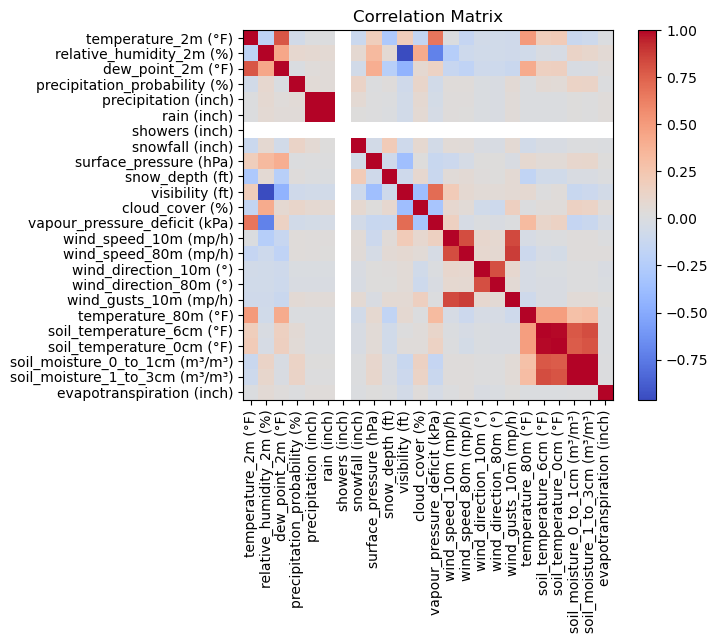

In [138]:
corr_matrix = num_weather.corr()
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title('Correlation Matrix')
plt.show()

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Load data
df = pd.read_csv('6LocationsCleaned.csv')

# Preprocessing
def preprocess_data(df):
    # Convert time to datetime and extract features
    df['time'] = pd.to_datetime(df['time'])
    df['hour'] = df['time'].dt.hour
    df['day_of_year'] = df['time'].dt.dayofyear
    
    # Handle missing values
    df.fillna(method='ffill', inplace=True)
    
    return df

df_processed = preprocess_data(df)

# Define target variable (next hour's temperature)
target = 'temperature_2m (°F)'
df_processed['target'] = df_processed[target].shift(-1)

# Remove rows where target is NA (last hour)
df_processed.dropna(subset=['target'], inplace=True)

# Split data
X = df_processed.drop(columns=['target', 'time'])
y = df_processed['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build models
# Random Forest
rf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_model.fit(X_train, y_train)

# XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
xgb_model.fit(X_train, y_train)

# Evaluate models
def evaluate_model(model, X_test, y_test):
    
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds, squared=False)
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")
    
print("Random Forest:")
evaluate_model(rf_model, X_test, y_test)

print("\nXGBoost:")
evaluate_model(xgb_model, X_test, y_test)

C:\Users\emaqu\AppData\Local\Temp\ipykernel_5316\938160402.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Random Forest:
MAE: 0.97, RMSE: 1.41

XGBoost:
MAE: 0.96, RMSE: 1.37


C:\Users\emaqu\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\emaqu\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Generating Temperature Prediction Model Visualizations...

1. Plotting Predictions vs Actual...

2. Creating Regression Evaluation Plots...

3. Analyzing Feature Importance...
Top 5 Features (Random Forest):
temperature_2m (°F): 0.9845
hour: 0.0075
cloud_cover (%): 0.0010
surface_pressure (hPa): 0.0010
dew_point_2m (°F): 0.0009

Top 5 Features (XGBoost):
temperature_2m (°F): 0.9841
hour: 0.0056
dew_point_2m (°F): 0.0018
cloud_cover (%): 0.0013
soil_temperature_0cm (°F): 0.0009

4. Analyzing Error Patterns...

5. Comparing Model Performance...
Random Forest - MAE: 0.967, RMSE: 1.408, R²: 0.994
XGBoost - MAE: 0.960, RMSE: 1.369, R²: 0.994

All visualizations complete!


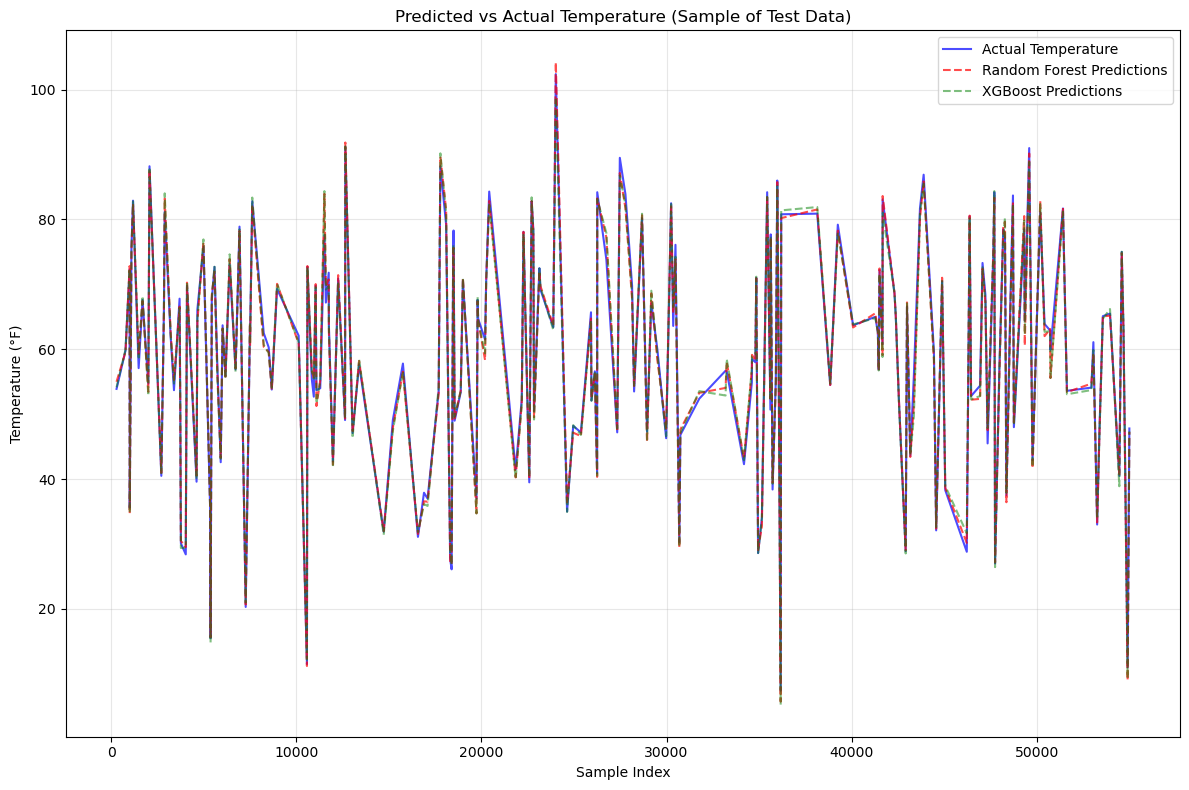

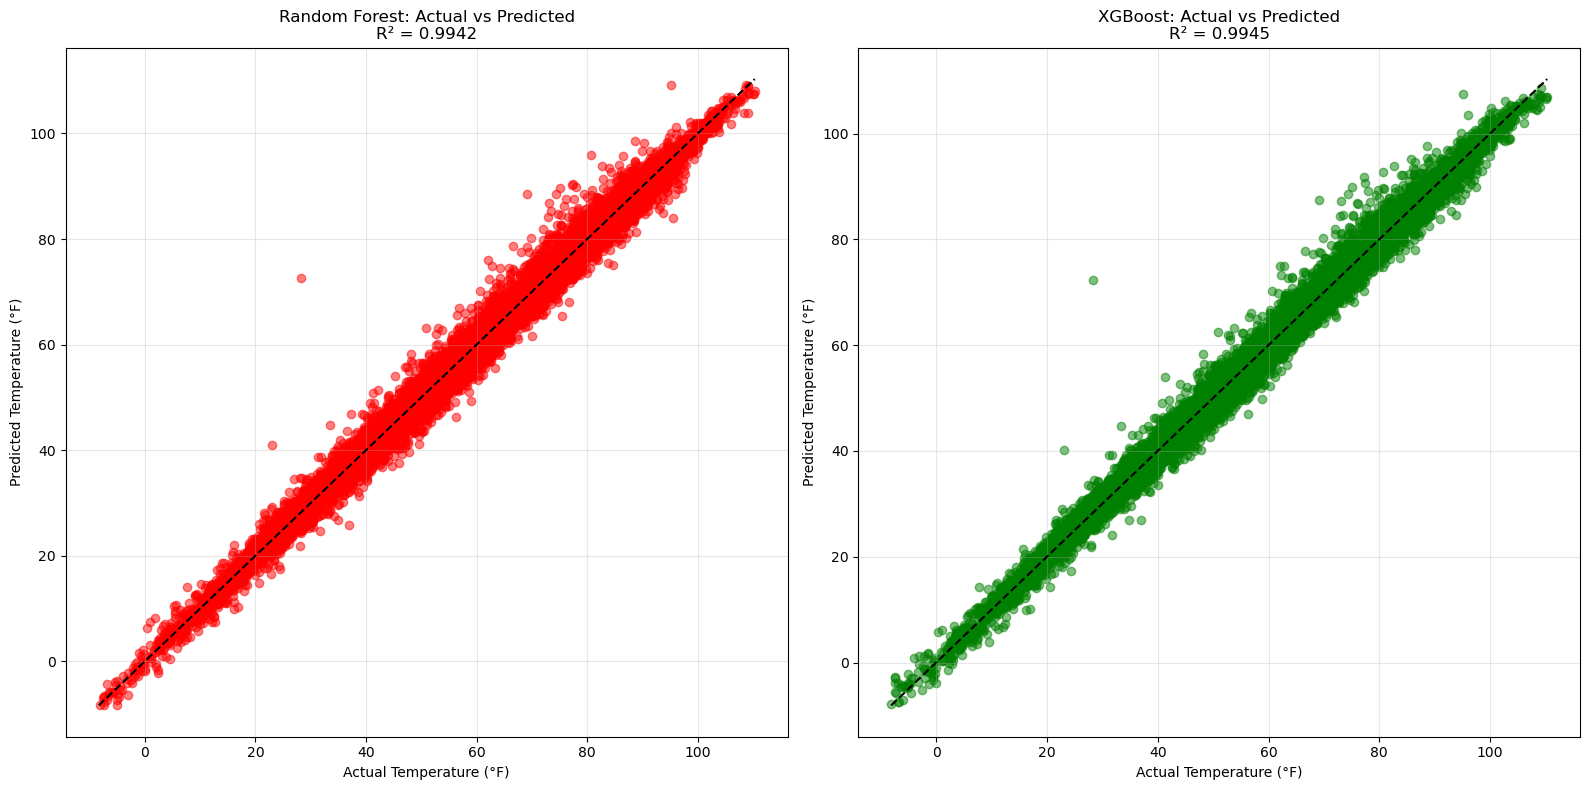

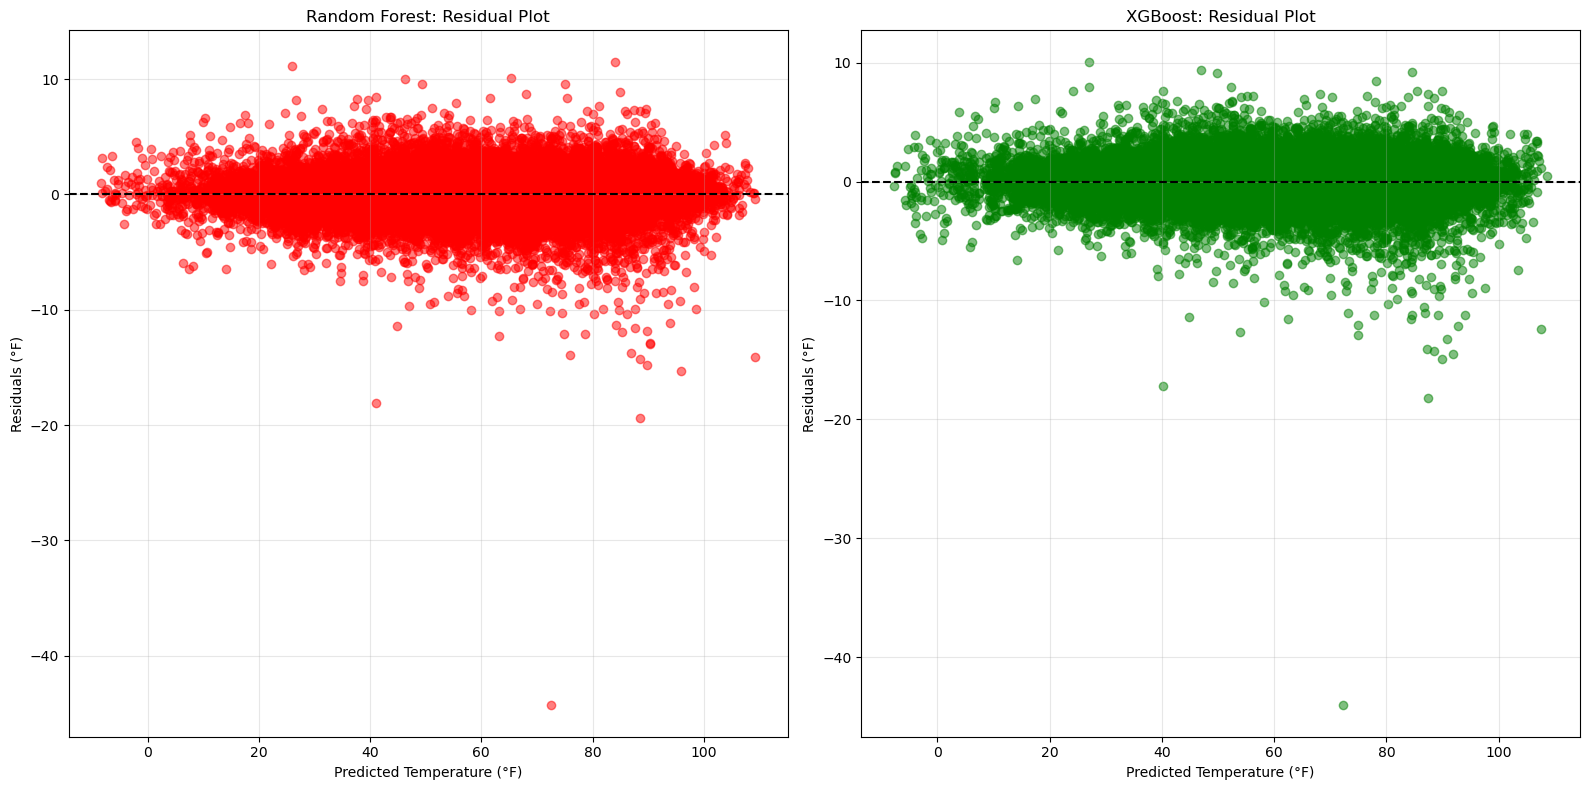

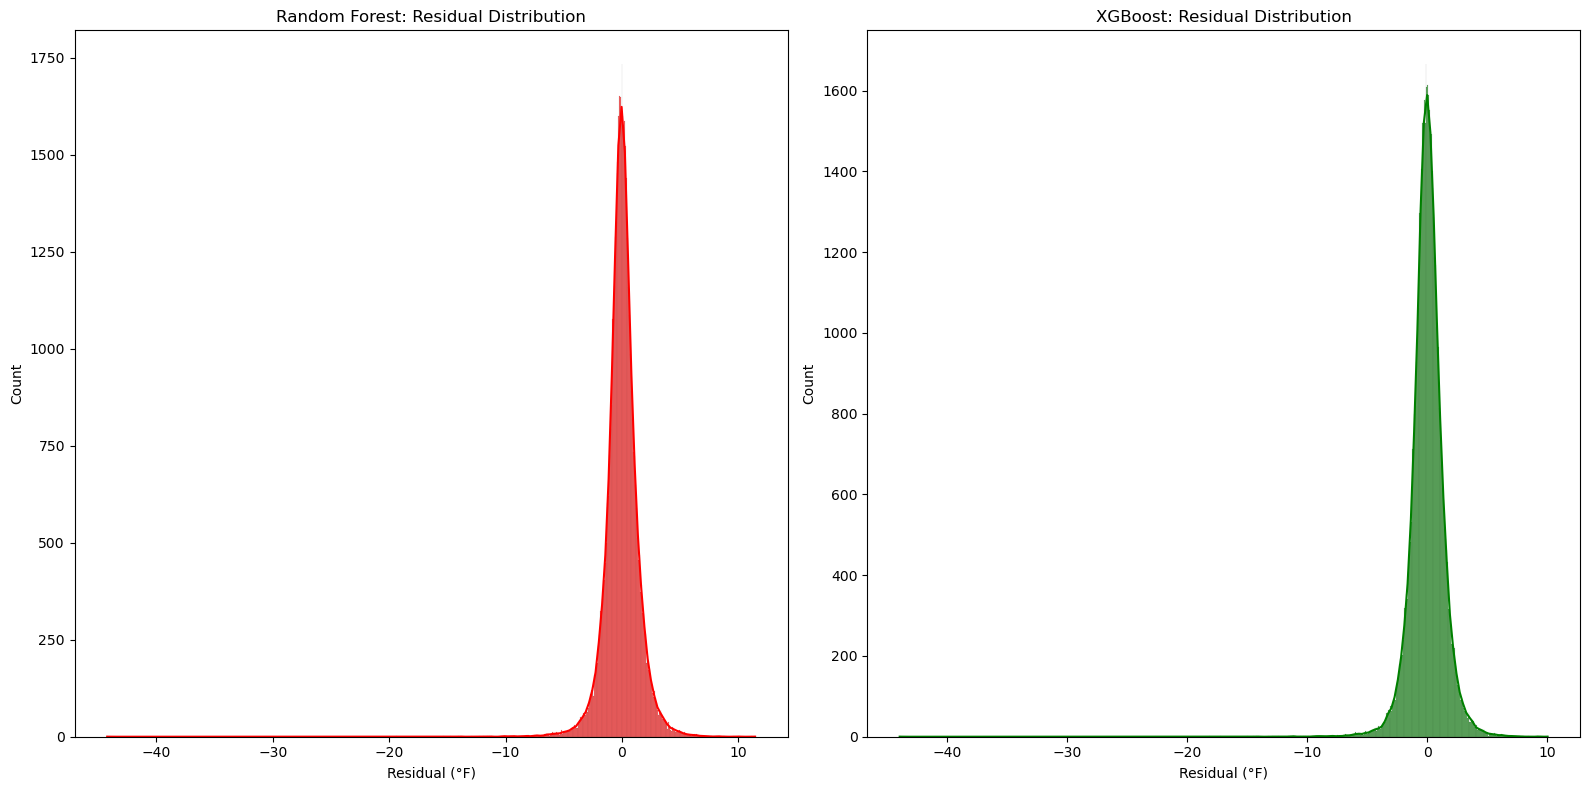

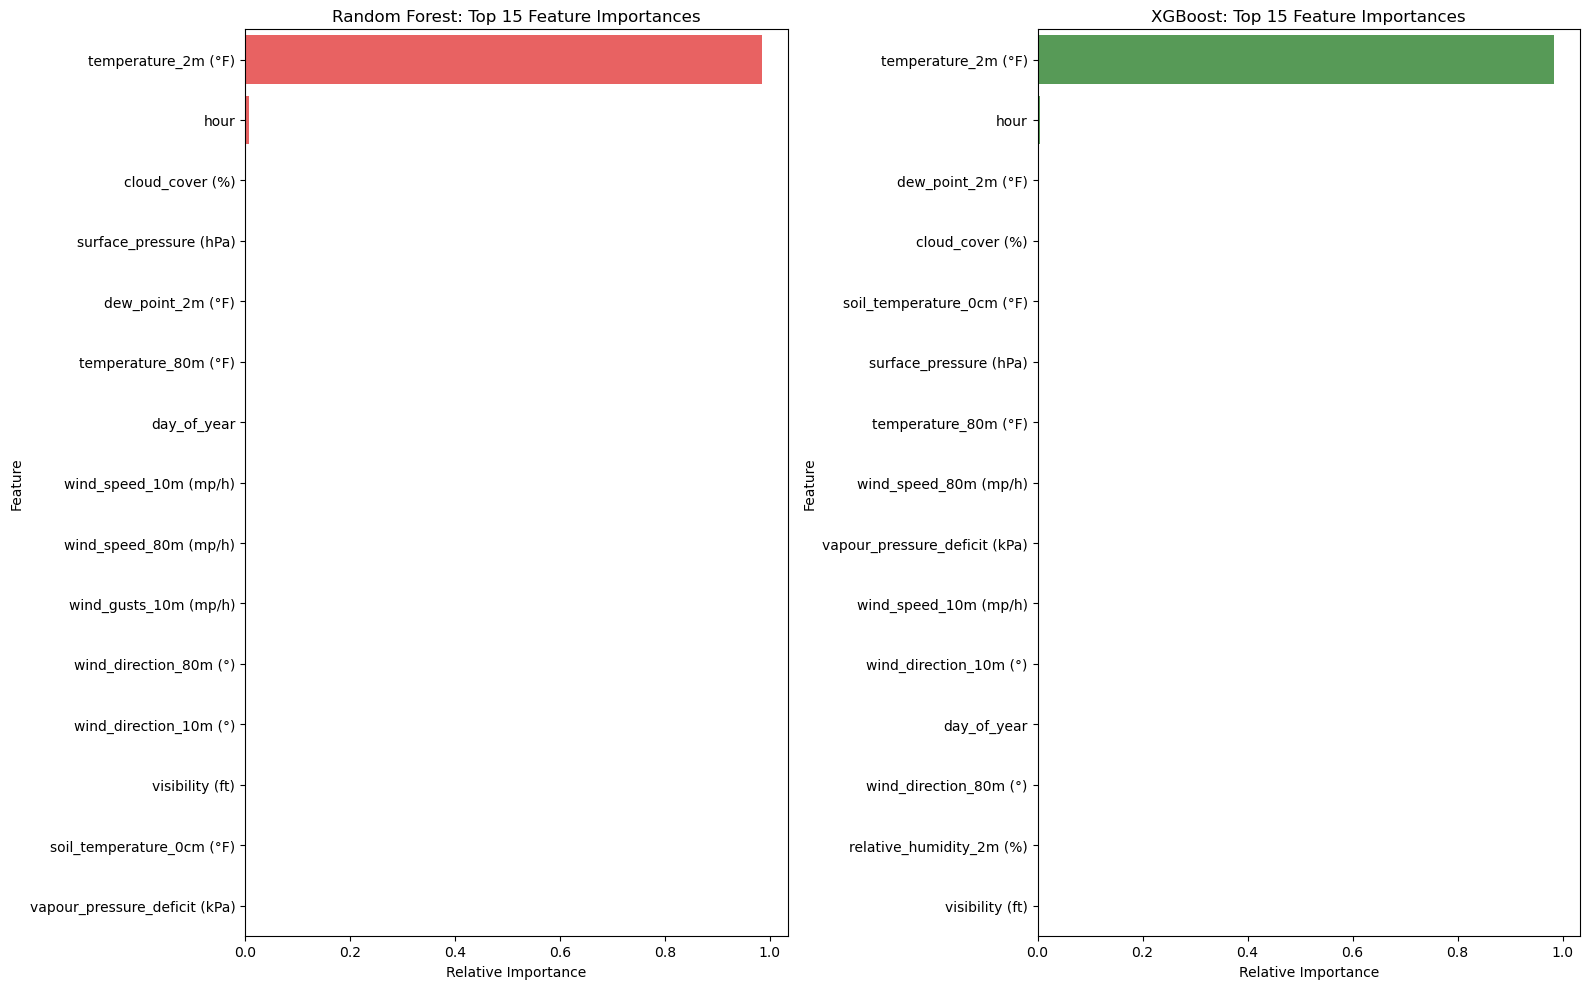

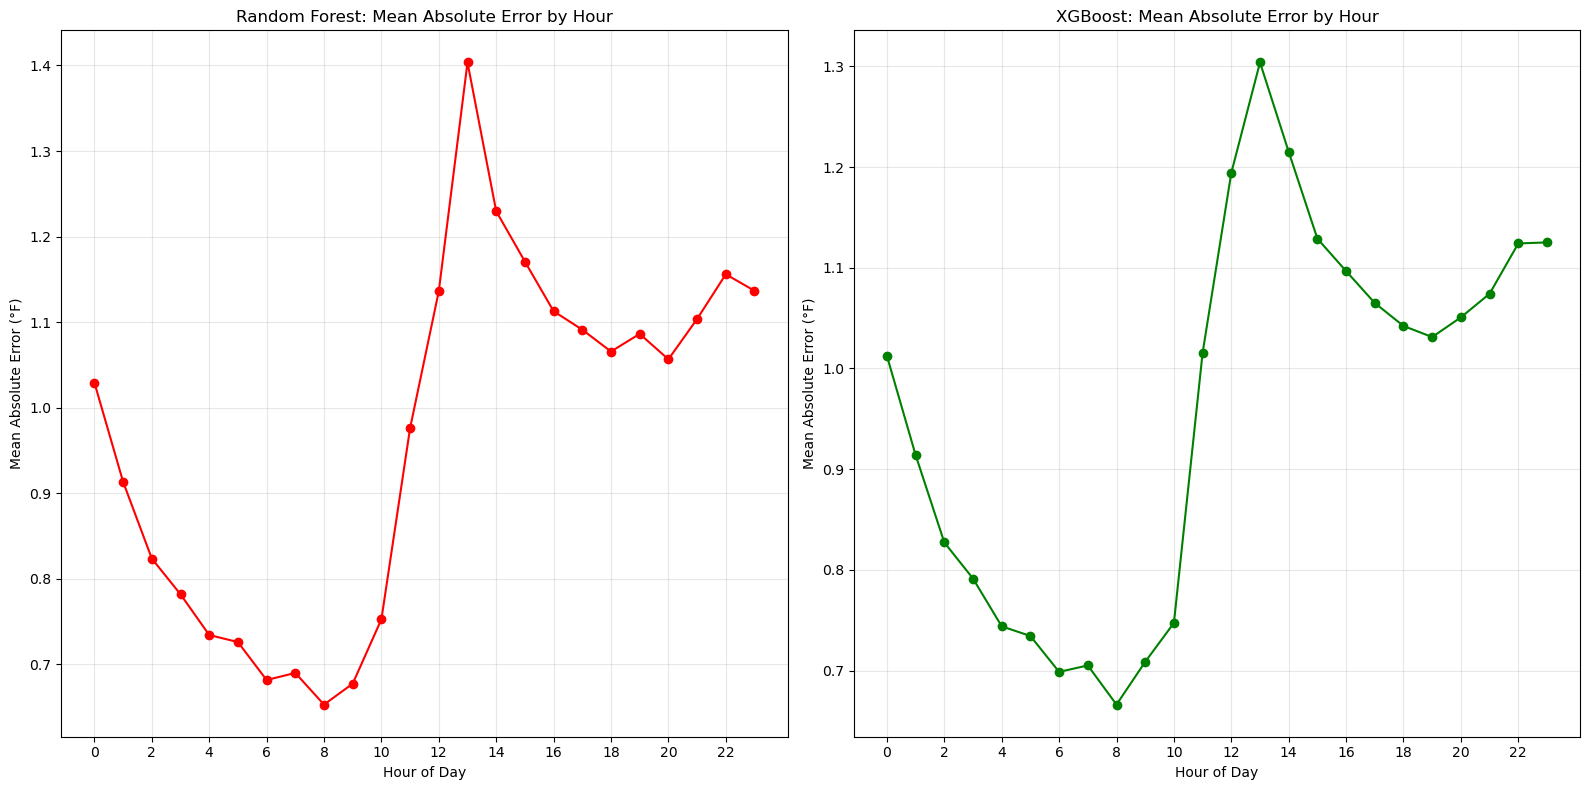

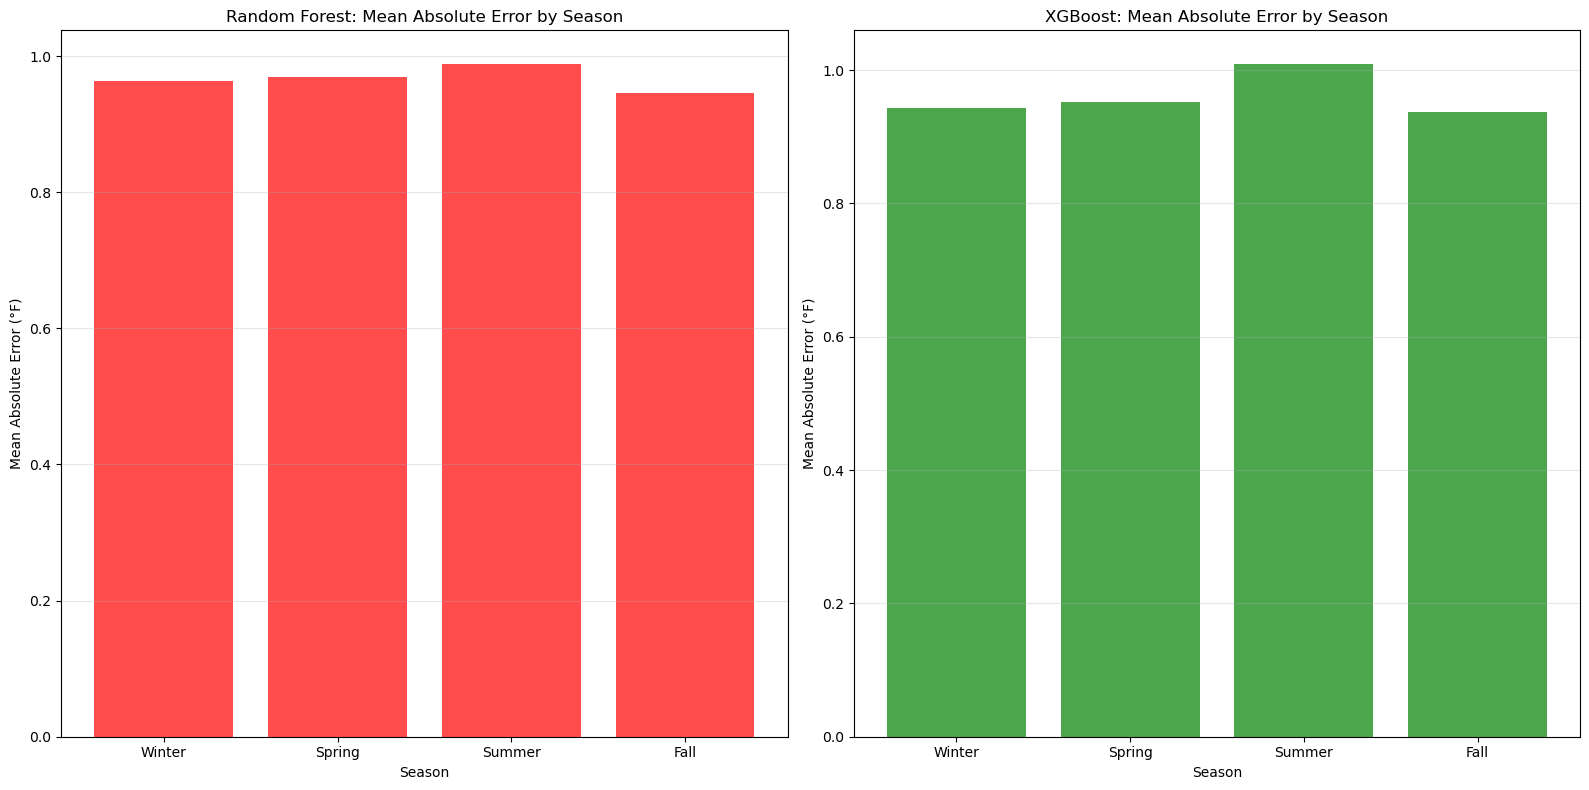

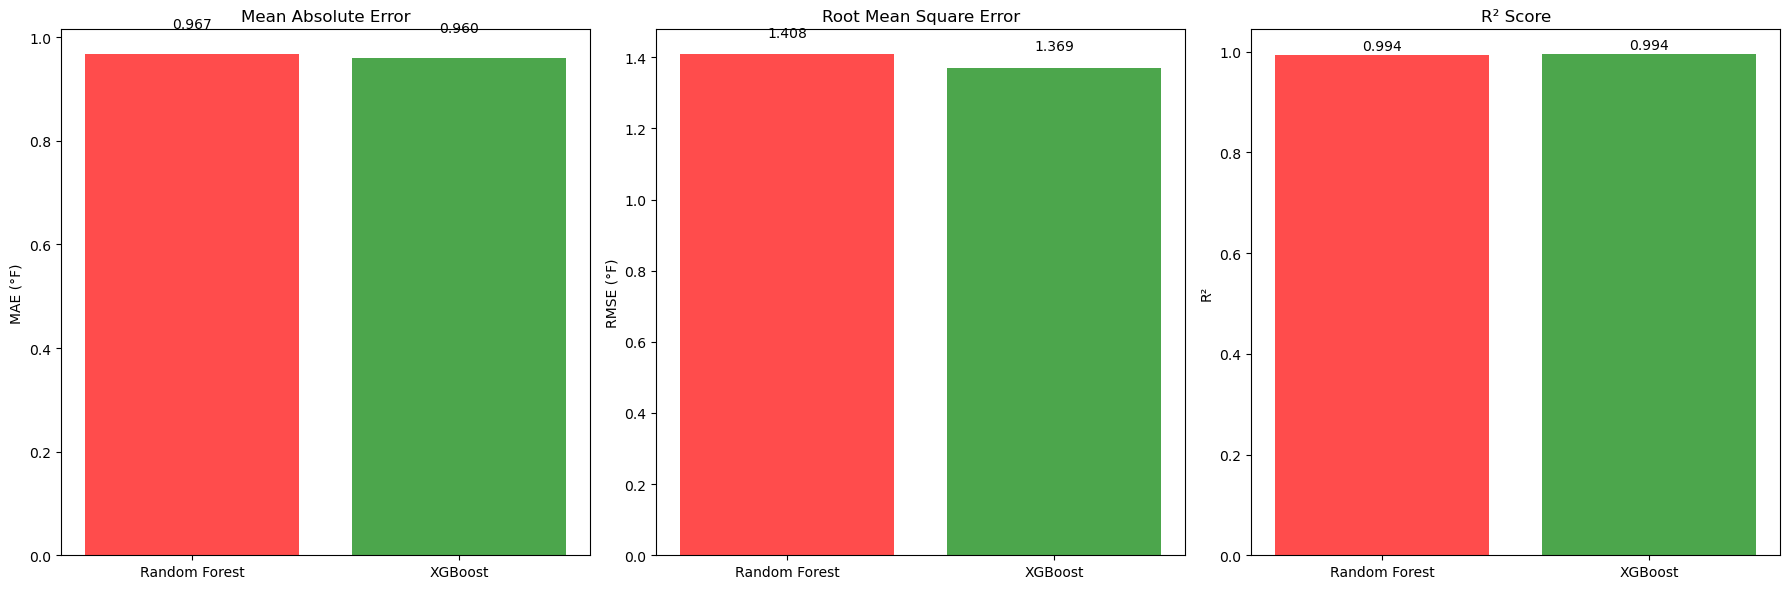

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance
import matplotlib.dates as mdates

# Make predictions
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# 1. Prediction vs Actual Plot
def plot_predictions_vs_actual(y_true, y_pred_rf, y_pred_xgb):
    plt.figure(figsize=(12, 8))
    
    # Take a sample if we have too many points
    if len(y_true) > 200:
        indices = np.random.choice(range(len(y_true)), 200, replace=False)
        indices = sorted(indices)
        y_sample = y_true.iloc[indices]
        y_pred_rf_sample = y_pred_rf[indices]
        y_pred_xgb_sample = y_pred_xgb[indices]
    else:
        y_sample = y_true
        y_pred_rf_sample = y_pred_rf
        y_pred_xgb_sample = y_pred_xgb
        indices = range(len(y_sample))
    
    plt.plot(indices, y_sample, 'b-', label='Actual Temperature', alpha=0.7)
    plt.plot(indices, y_pred_rf_sample, 'r--', label='Random Forest Predictions', alpha=0.7)
    plt.plot(indices, y_pred_xgb_sample, 'g--', label='XGBoost Predictions', alpha=0.5)
    
    plt.title('Predicted vs Actual Temperature (Sample of Test Data)')
    plt.xlabel('Sample Index')
    plt.ylabel('Temperature (°F)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

# 2. Regression Evaluation Plots
def plot_regression_evaluation(y_true, y_pred_rf, y_pred_xgb):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Random Forest
    axes[0].scatter(y_true, y_pred_rf, alpha=0.5, color='red')
    
    # Plot perfect prediction line
    min_val = min(y_true.min(), y_pred_rf.min())
    max_val = max(y_true.max(), y_pred_rf.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'k--')
    
    r2_rf = r2_score(y_true, y_pred_rf)
    axes[0].set_title(f'Random Forest: Actual vs Predicted\nR² = {r2_rf:.4f}')
    axes[0].set_xlabel('Actual Temperature (°F)')
    axes[0].set_ylabel('Predicted Temperature (°F)')
    axes[0].grid(True, alpha=0.3)
    
    # XGBoost
    axes[1].scatter(y_true, y_pred_xgb, alpha=0.5, color='green')
    
    # Plot perfect prediction line
    min_val = min(y_true.min(), y_pred_xgb.min())
    max_val = max(y_true.max(), y_pred_xgb.max())
    axes[1].plot([min_val, max_val], [min_val, max_val], 'k--')
    
    r2_xgb = r2_score(y_true, y_pred_xgb)
    axes[1].set_title(f'XGBoost: Actual vs Predicted\nR² = {r2_xgb:.4f}')
    axes[1].set_xlabel('Actual Temperature (°F)')
    axes[1].set_ylabel('Predicted Temperature (°F)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Create residual plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Random Forest residuals
    residuals_rf = y_true - y_pred_rf
    axes[0].scatter(y_pred_rf, residuals_rf, alpha=0.5, color='red')
    axes[0].axhline(y=0, color='k', linestyle='--')
    axes[0].set_title('Random Forest: Residual Plot')
    axes[0].set_xlabel('Predicted Temperature (°F)')
    axes[0].set_ylabel('Residuals (°F)')
    axes[0].grid(True, alpha=0.3)
    
    # XGBoost residuals
    residuals_xgb = y_true - y_pred_xgb
    axes[1].scatter(y_pred_xgb, residuals_xgb, alpha=0.5, color='green')
    axes[1].axhline(y=0, color='k', linestyle='--')
    axes[1].set_title('XGBoost: Residual Plot')
    axes[1].set_xlabel('Predicted Temperature (°F)')
    axes[1].set_ylabel('Residuals (°F)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Show distribution of residuals
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    sns.histplot(residuals_rf, kde=True, ax=axes[0], color='red', alpha=0.6)
    axes[0].set_title('Random Forest: Residual Distribution')
    axes[0].set_xlabel('Residual (°F)')
    
    sns.histplot(residuals_xgb, kde=True, ax=axes[1], color='green', alpha=0.6)
    axes[1].set_title('XGBoost: Residual Distribution')
    axes[1].set_xlabel('Residual (°F)')
    
    plt.tight_layout()

# 3. Feature Importance Plots
def plot_feature_importance(rf_model, xgb_model, feature_names):
    # Extract feature importances
    rf_importances = rf_model.named_steps['model'].feature_importances_
    xgb_importances = xgb_model.feature_importances_
    
    # Convert feature names to list if needed
    if isinstance(feature_names, pd.Index):
        feature_names = list(feature_names)
    
    # Create DataFrames for easier handling
    rf_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': rf_importances
    }).sort_values('Importance', ascending=False)
    
    xgb_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': xgb_importances
    }).sort_values('Importance', ascending=False)
    
    # Plot feature importances
    fig, axes = plt.subplots(1, 2, figsize=(16, 10))
    
    # Random Forest
    sns.barplot(x='Importance', y='Feature', data=rf_importance_df.head(15), ax=axes[0], color='red', alpha=0.7)
    axes[0].set_title('Random Forest: Top 15 Feature Importances')
    axes[0].set_xlabel('Relative Importance')
    axes[0].set_ylabel('Feature')
    
    # XGBoost
    sns.barplot(x='Importance', y='Feature', data=xgb_importance_df.head(15), ax=axes[1], color='green', alpha=0.7)
    axes[1].set_title('XGBoost: Top 15 Feature Importances')
    axes[1].set_xlabel('Relative Importance')
    axes[1].set_ylabel('Feature')
    
    plt.tight_layout()
    
    # Print top 5 features for each model
    print("Top 5 Features (Random Forest):")
    for i, row in rf_importance_df.head(5).iterrows():
        print(f"{row['Feature']}: {row['Importance']:.4f}")
    
    print("\nTop 5 Features (XGBoost):")
    for i, row in xgb_importance_df.head(5).iterrows():
        print(f"{row['Feature']}: {row['Importance']:.4f}")

# 4. Error Analysis by Hour and Season
def plot_error_analysis(y_true, y_pred_rf, y_pred_xgb, df):
    # Create a DataFrame with predictions and errors
    error_df = pd.DataFrame({
        'y_true': y_true,
        'rf_pred': y_pred_rf,
        'xgb_pred': y_pred_xgb,
        'rf_error': np.abs(y_true - y_pred_rf),
        'xgb_error': np.abs(y_true - y_pred_xgb)
    })
    
    # Get hour and day_of_year from the same indices as y_true
    # We'll need to align indices
    error_df['hour'] = df.loc[y_true.index, 'hour'].values
    error_df['day_of_year'] = df.loc[y_true.index, 'day_of_year'].values
    
    # Season approximation (Northern Hemisphere)
    def get_season(day):
        if 1 <= day <= 60 or 335 <= day <= 366:  # Winter (Dec-Feb)
            return 'Winter'
        elif 61 <= day <= 152:  # Spring (Mar-May)
            return 'Spring'
        elif 153 <= day <= 244:  # Summer (Jun-Aug)
            return 'Summer'
        else:  # Fall (Sep-Nov)
            return 'Fall'
    
    error_df['season'] = error_df['day_of_year'].apply(get_season)
    
    # Error by hour
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    hour_error_rf = error_df.groupby('hour')['rf_error'].mean()
    hour_error_xgb = error_df.groupby('hour')['xgb_error'].mean()
    
    axes[0].plot(hour_error_rf.index, hour_error_rf.values, 'r-', marker='o')
    axes[0].set_title('Random Forest: Mean Absolute Error by Hour')
    axes[0].set_xlabel('Hour of Day')
    axes[0].set_ylabel('Mean Absolute Error (°F)')
    axes[0].set_xticks(range(0, 24, 2))
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(hour_error_xgb.index, hour_error_xgb.values, 'g-', marker='o')
    axes[1].set_title('XGBoost: Mean Absolute Error by Hour')
    axes[1].set_xlabel('Hour of Day')
    axes[1].set_ylabel('Mean Absolute Error (°F)')
    axes[1].set_xticks(range(0, 24, 2))
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Error by season
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    season_order = ['Winter', 'Spring', 'Summer', 'Fall']
    season_error_rf = error_df.groupby('season')['rf_error'].mean().reindex(season_order)
    season_error_xgb = error_df.groupby('season')['xgb_error'].mean().reindex(season_order)
    
    axes[0].bar(season_error_rf.index, season_error_rf.values, color='red', alpha=0.7)
    axes[0].set_title('Random Forest: Mean Absolute Error by Season')
    axes[0].set_xlabel('Season')
    axes[0].set_ylabel('Mean Absolute Error (°F)')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    axes[1].bar(season_error_xgb.index, season_error_xgb.values, color='green', alpha=0.7)
    axes[1].set_title('XGBoost: Mean Absolute Error by Season')
    axes[1].set_xlabel('Season')
    axes[1].set_ylabel('Mean Absolute Error (°F)')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()

# 5. Model Comparison
def model_comparison(y_true, y_pred_rf, y_pred_xgb):
    # Calculate metrics
    rf_mae = mean_absolute_error(y_true, y_pred_rf)
    rf_rmse = np.sqrt(mean_squared_error(y_true, y_pred_rf))
    rf_r2 = r2_score(y_true, y_pred_rf)
    
    xgb_mae = mean_absolute_error(y_true, y_pred_xgb)
    xgb_rmse = np.sqrt(mean_squared_error(y_true, y_pred_xgb))
    xgb_r2 = r2_score(y_true, y_pred_xgb)
    
    # Create bar chart
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    models = ['Random Forest', 'XGBoost']
    mae_values = [rf_mae, xgb_mae]
    rmse_values = [rf_rmse, xgb_rmse]
    r2_values = [rf_r2, xgb_r2]
    
    # MAE
    axes[0].bar(models, mae_values, color=['red', 'green'], alpha=0.7)
    axes[0].set_title('Mean Absolute Error')
    axes[0].set_ylabel('MAE (°F)')
    for i, v in enumerate(mae_values):
        axes[0].text(i, v + 0.05, f'{v:.3f}', ha='center')
    
    # RMSE
    axes[1].bar(models, rmse_values, color=['red', 'green'], alpha=0.7)
    axes[1].set_title('Root Mean Square Error')
    axes[1].set_ylabel('RMSE (°F)')
    for i, v in enumerate(rmse_values):
        axes[1].text(i, v + 0.05, f'{v:.3f}', ha='center')
    
    # R2
    axes[2].bar(models, r2_values, color=['red', 'green'], alpha=0.7)
    axes[2].set_title('R² Score')
    axes[2].set_ylabel('R²')
    for i, v in enumerate(r2_values):
        axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center')
    
    plt.tight_layout()
    
    # Print metrics
    print(f"Random Forest - MAE: {rf_mae:.3f}, RMSE: {rf_rmse:.3f}, R²: {rf_r2:.3f}")
    print(f"XGBoost - MAE: {xgb_mae:.3f}, RMSE: {xgb_rmse:.3f}, R²: {xgb_r2:.3f}")

# Run all visualizations
print("Generating Temperature Prediction Model Visualizations...")

# 1. Predictions vs Actual
print("\n1. Plotting Predictions vs Actual...")
plot_predictions_vs_actual(y_test, rf_preds, xgb_preds)

# 2. Regression Evaluation
print("\n2. Creating Regression Evaluation Plots...")
plot_regression_evaluation(y_test, rf_preds, xgb_preds)

# 3. Feature Importance
print("\n3. Analyzing Feature Importance...")
plot_feature_importance(rf_model, xgb_model, X.columns)

# 4. Error Analysis
print("\n4. Analyzing Error Patterns...")
plot_error_analysis(y_test, rf_preds, xgb_preds, df_processed)

# 5. Model Comparison
print("\n5. Comparing Model Performance...")
model_comparison(y_test, rf_preds, xgb_preds)

print("\nAll visualizations complete!")
plt.show()

In [120]:
import pandas as pd

# Load the emission_by_unit and emission_by_fuel data
# Skip the first few rows if they contain metadata or comments
emission_by_unit = pd.read_csv('emissions_by_unit.csv', skiprows=6, low_memory=False)
emission_by_fuel = pd.read_csv('emissions_by_fuel.csv', skiprows=5, low_memory=False)

# Check the column names and ensure they are correctly loaded
print(emission_by_unit.columns)
print(emission_by_fuel.columns)

# Clean column names by stripping any extra whitespace
emission_by_unit.columns = emission_by_unit.columns.str.strip()
emission_by_fuel.columns = emission_by_fuel.columns.str.strip()

# Verify if the column names are consistent between the two datasets
print(set(emission_by_unit.columns).intersection(set(emission_by_fuel.columns)))

# Now, merge the two datasets based on the common columns
merged_data = pd.merge(emission_by_unit, emission_by_fuel, 
                       on=['Facility Id', 'FRS Id', 'Facility Name', 'City', 'State', 
                           'Primary NAICS Code', 'Reporting Year', 'Industry Type (subparts)', 
                           'Industry Type (sectors)', 'Unit Name'], 
                       how='outer')

# Display the merged data
print(merged_data.head())

# Save the merged dataset to a new CSV file
merged_data.to_csv('combined_emissions_data.csv', index=False)

Index(['Facility Id', 'FRS Id', 'Facility Name', 'City', 'State',
       'Primary NAICS Code', 'Reporting Year', 'Industry Type (subparts)',
       'Industry Type (sectors)', 'Unit Name', 'Unit Type',
       'Unit Reporting Method',
       'Unit Maximum Rated Heat Input Capacity (mmBTU/hr)',
       'Unit CO2 emissions (non-biogenic) ', 'Unit Methane (CH4) emissions ',
       'Unit Nitrous Oxide (N2O) emissions ',
       'Unit Biogenic CO2 emissions (metric tons)'],
      dtype='object')
Index(['Facility Id', 'FRS Id', 'Facility Name', 'City', 'State',
       'Primary NAICS Code', 'Reporting Year', 'Industry Type (subparts)',
       'Industry Type (sectors)', 'Unit Name', 'General Fuel Type',
       'Specific Fuel Type', 'Other Fuel Name', 'Blend Fuel Name',
       'Fuel Methane (CH4) emissions (mt CO2e)',
       'Fuel Nitrous Oxide (N2O) emissions (mt CO2e)'],
      dtype='object')
{'Primary NAICS Code', 'Unit Name', 'Facility Name', 'Industry Type (sectors)', 'Facility Id', 'City', 'F

In [121]:
# Step 1: Remove unwanted columns (e.g., columns that have no useful information for analysis)
# Let's assume "Unnamed" columns are unnecessary and we drop them
merged_data_clean = merged_data.drop(columns=[col for col in merged_data.columns if 'Unnamed' in col])

# Step 2: Handle missing values
# Display the count of missing values for each column
print(merged_data_clean.isnull().sum())

# Drop rows with too many missing values or irrelevant data
# You can choose a threshold for dropping, for example, removing rows with more than 50% missing values
threshold = len(merged_data_clean.columns) * 0.5
merged_data_clean = merged_data_clean.dropna(thresh=threshold)

# For other missing values, we can fill them with a suitable strategy (e.g., mean for numerical, mode for categorical)
# Here we'll fill missing numerical values with the column mean and categorical with the mode
for column in merged_data_clean.columns:
    if merged_data_clean[column].dtype == 'object':  # Categorical columns
        merged_data_clean[column].fillna(merged_data_clean[column].mode()[0], inplace=True)
    else:  # Numerical columns
        merged_data_clean[column].fillna(merged_data_clean[column].mean(), inplace=True)

# Step 3: Convert data types
# Convert necessary columns to the correct data type (e.g., converting year to int, NAICS codes to categorical)
merged_data_clean['Reporting Year'] = pd.to_numeric(merged_data_clean['Reporting Year'], errors='coerce').fillna(0).astype(int)
merged_data_clean['Primary NAICS Code'] = merged_data_clean['Primary NAICS Code'].astype('category')

# Step 4: Remove duplicates
merged_data_clean.drop_duplicates(inplace=True)

# Step 5: Handle outliers
# Depending on your data, you may need to handle outliers, for example:
# Use z-score or IQR to detect and remove outliers from numerical columns

# Here's an example using IQR for outlier detection in a numerical column like emissions data
Q1 = merged_data_clean['Fuel Methane (CH4) emissions (mt CO2e)'].quantile(0.25)
Q3 = merged_data_clean['Fuel Methane (CH4) emissions (mt CO2e)'].quantile(0.75)
IQR = Q3 - Q1
# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Remove outliers
merged_data_clean = merged_data_clean[(merged_data_clean['Fuel Methane (CH4) emissions (mt CO2e)'] >= lower_bound) & 
                                      (merged_data_clean['Fuel Methane (CH4) emissions (mt CO2e)'] <= upper_bound)]

# Step 6: Standardize or normalize numerical columns (optional, depending on the analysis you plan to perform)
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
numerical_columns = ['Fuel Methane (CH4) emissions (mt CO2e)', 'Fuel Nitrous Oxide (N2O) emissions (mt CO2e)']

# Apply standardization
scaler = StandardScaler()
merged_data_clean[numerical_columns] = scaler.fit_transform(merged_data_clean[numerical_columns])

# Step 7: Save the cleaned data to a new file
merged_data_clean.to_csv('cleaned_emissions_data.csv', index=False)

# Step 8: Verify the final clean dataset
print(merged_data_clean.info())
print(merged_data_clean.head())

Facility Id                                               0
FRS Id                                                32327
Facility Name                                             0
City                                                      0
State                                                     0
Primary NAICS Code                                       29
Reporting Year                                            0
Industry Type (subparts)                                  0
Industry Type (sectors)                                  26
Unit Name                                                 0
Unit Type                                             10279
Unit Reporting Method                                  7687
Unit Maximum Rated Heat Input Capacity (mmBTU/hr)     80181
Unit CO2 emissions (non-biogenic)                         0
Unit Methane (CH4) emissions                              0
Unit Nitrous Oxide (N2O) emissions                        0
Unit Biogenic CO2 emissions (metric tons

C:\Users\emaqu\AppData\Local\Temp\ipykernel_3292\3715703650.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_data_clean[column].fillna(merged_data_clean[column].mean(), inplace=True)
C:\Users\emaqu\AppData\Local\Temp\ipykernel_3292\3715703650.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

<class 'pandas.core.frame.DataFrame'>
Index: 272226 entries, 0 to 323495
Data columns (total 23 columns):
 #   Column                                             Non-Null Count   Dtype   
---  ------                                             --------------   -----   
 0   Facility Id                                        272226 non-null  int64   
 1   FRS Id                                             272226 non-null  float64 
 2   Facility Name                                      272226 non-null  object  
 3   City                                               272226 non-null  object  
 4   State                                              272226 non-null  object  
 5   Primary NAICS Code                                 272226 non-null  category
 6   Reporting Year                                     272226 non-null  int32   
 7   Industry Type (subparts)                           272226 non-null  object  
 8   Industry Type (sectors)                            272226 non-null  o

In [122]:
# Load dataset
df = pd.read_csv('Renewable_Energy_Usage_Sampled.csv')

# Check first few rows
df.head()

# Check data types and missing values
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Household_ID       1000 non-null   object 
 1   Region             1000 non-null   object 
 2   Country            1000 non-null   object 
 3   Energy_Source      1000 non-null   object 
 4   Monthly_Usage_kWh  1000 non-null   float64
 5   Year               1000 non-null   int64  
 6   Household_Size     1000 non-null   int64  
 7   Income_Level       1000 non-null   object 
 8   Urban_Rural        1000 non-null   object 
 9   Adoption_Year      1000 non-null   int64  
 10  Subsidy_Received   1000 non-null   object 
 11  Cost_Savings_USD   1000 non-null   float64
dtypes: float64(2), int64(3), object(7)
memory usage: 93.9+ KB


,Monthly_Usage_kWh,Year,Household_Size,Adoption_Year,Cost_Savings_USD
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,767.325530,2021.992000,4.480000,2015.992000,248.389850
std,419.649102,1.419137,2.297581,3.973629,143.127301
min,50.740000,2020.000000,1.000000,2010.000000,10.420000
25%,402.730000,2021.000000,2.000000,2013.000000,122.122500
50%,760.190000,2022.000000,5.000000,2016.000000,242.530000
75%,1117.747500,2023.000000,6.000000,2019.000000,372.520000
max,1497.340000,2024.000000,8.000000,2024.000000,499.830000


In [154]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load emissions data
emissions = pd.read_csv('cleaned_emissions_data.csv')

# Feature engineering
def preprocess_emissions(df):
    # Convert categoricals
    df['State'] = df['State'].astype('category')
    df['Primary NAICS Code'] = df['Primary NAICS Code'].astype('category')
    df['General Fuel Type'] = df['General Fuel Type'].astype('category')
    
    # Create efficiency metric
    df['Efficiency'] = df['Unit CO2 emissions (non-biogenic)'] / df['Unit Maximum Rated Heat Input Capacity (mmBTU/hr)']
    
    return df

emissions_processed = preprocess_emissions(emissions)

# Define target (CO2 emissions)
X_emis = emissions_processed.drop(columns=['Unit CO2 emissions (non-biogenic)',
                                         'Facility Id', 'FRS Id', 'Facility Name', 'City'])
y_emis = emissions_processed['Unit CO2 emissions (non-biogenic)']

# Preprocessing pipeline
categorical_features = ['State', 'Primary NAICS Code', 'General Fuel Type', 'Unit Type', 'Unit Reporting Method']
numeric_features = ['Unit Maximum Rated Heat Input Capacity (mmBTU/hr)', 'Reporting Year']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Model pipeline
emis_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100))
])

# Train-test split
X_train_emis, X_test_emis, y_train_emis, y_test_emis = train_test_split(
    X_emis, y_emis, test_size=0.2, random_state=42)

# Train model
emis_model.fit(X_train_emis, y_train_emis)

# Evaluate
emis_preds = emis_model.predict(X_test_emis)
print(f"Emissions Model MAE: {mean_absolute_error(y_test_emis, emis_preds):.2f} metric tons")

Emissions Model MAE: 55850.25 metric tons


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Load data
emissions = pd.read_csv('cleaned_emissions_data.csv')

# Data cleaning function
def clean_emissions_data(df):
    # Replace infinities with NaNs
    df = df.replace([np.inf, -np.inf], np.nan)
    
    # Remove extremely large values (adjust threshold as needed)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].apply(lambda x: np.where(x > 1e10, np.nan, x))
    
    # Create meaningful features
    df['Efficiency_Ratio'] = df['Unit CO2 emissions (non-biogenic)'] / df['Unit Maximum Rated Heat Input Capacity (mmBTU/hr)']
    df['Efficiency_Ratio'] = np.where(~np.isfinite(df['Efficiency_Ratio']), np.nan, df['Efficiency_Ratio'])
    
    # Log transform target variable
    df['log_CO2'] = np.log1p(df['Unit CO2 emissions (non-biogenic)'])
    
    return df

emissions_clean = clean_emissions_data(emissions)

# Define target and features
target = 'log_CO2'  # Using log-transformed target
X = emissions_clean.drop(columns=['Unit CO2 emissions (non-biogenic)', 'log_CO2', 
                                'Facility Id', 'FRS Id', 'Facility Name', 'City'])
y = emissions_clean[target]

# Identify feature types
cat_features = ['State', 'Primary NAICS Code', 'General Fuel Type', 
               'Unit Type', 'Unit Reporting Method']
num_features = ['Unit Maximum Rated Heat Input Capacity (mmBTU/hr)', 
               'Efficiency_Ratio', 'Reporting Year']

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features)
    ])

# Simplified model pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Fit model
model.fit(X_train, y_train)

# Evaluation function
def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    # Convert back from log scale
    preds_actual = np.expm1(preds)
    y_test_actual = np.expm1(y_test)
    
    mae = mean_absolute_error(y_test_actual, preds_actual)
    print(f"MAE: {mae:.2f} metric tons")
    print(f"Mean Actual Emissions: {y_test_actual.mean():.2f} metric tons")
    print(f"Error Percentage: {(mae/y_test_actual.mean())*100:.2f}%")
    
    return preds_actual

print("Model Performance:")
predictions = evaluate_model(model, X_test, y_test)

Model Performance:
MAE: 219.99 metric tons
Mean Actual Emissions: 63602.99 metric tons
Error Percentage: 0.35%


Using existing test data...

=== Random Forest Regression Model Visualizations ===

Plotting regression evaluation...

Plotting feature importance...

Top 10 Most Important Features:
Feature 1: 0.5936
Feature 2: 0.3845
Feature 399: 0.0036
Feature 375: 0.0018
Feature 97: 0.0015
Feature 430: 0.0013
Feature 3: 0.0011
Feature 447: 0.0008
Feature 429: 0.0006
Feature 441: 0.0006

Plotting prediction distribution...


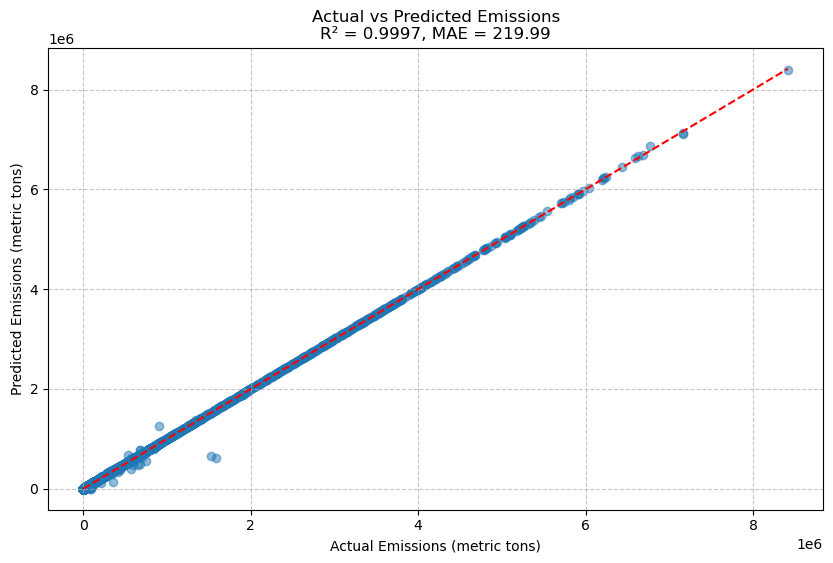

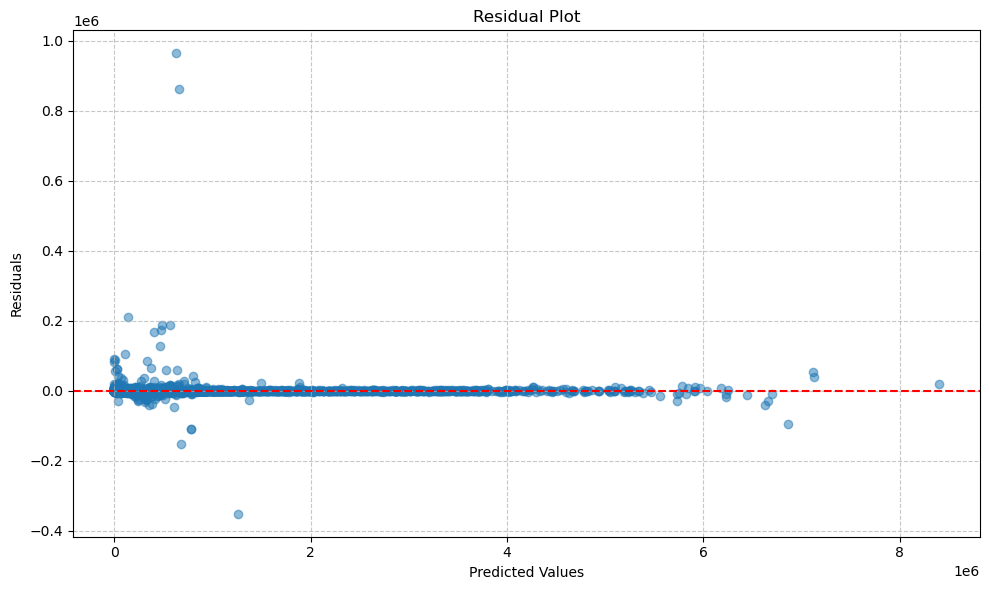

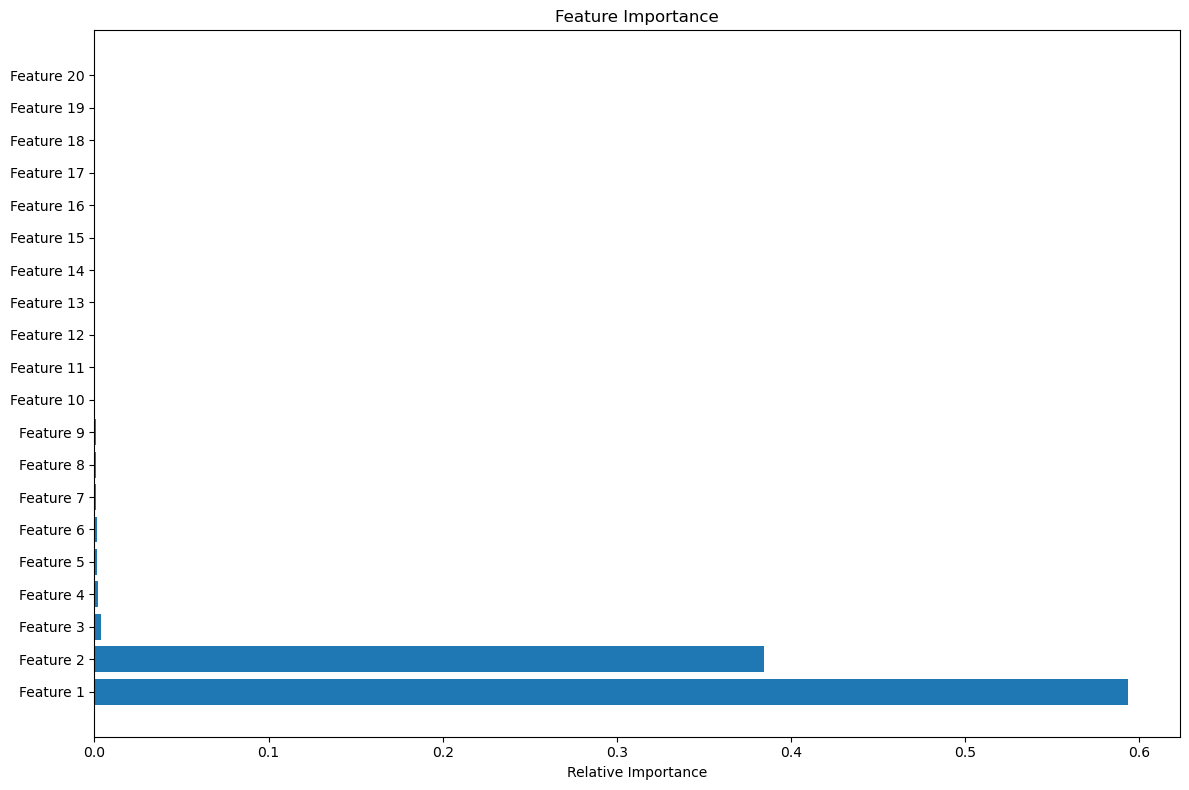

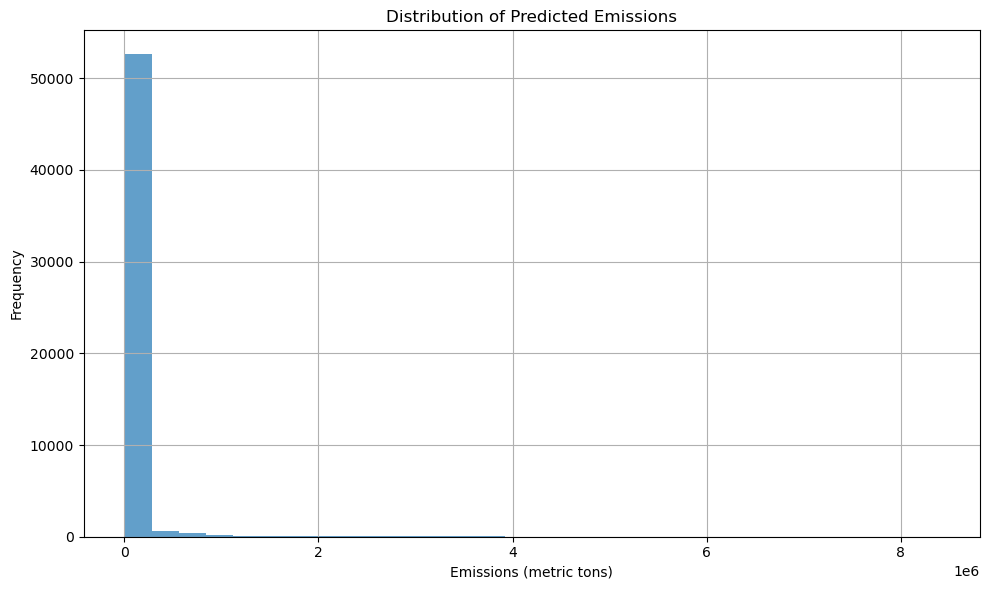

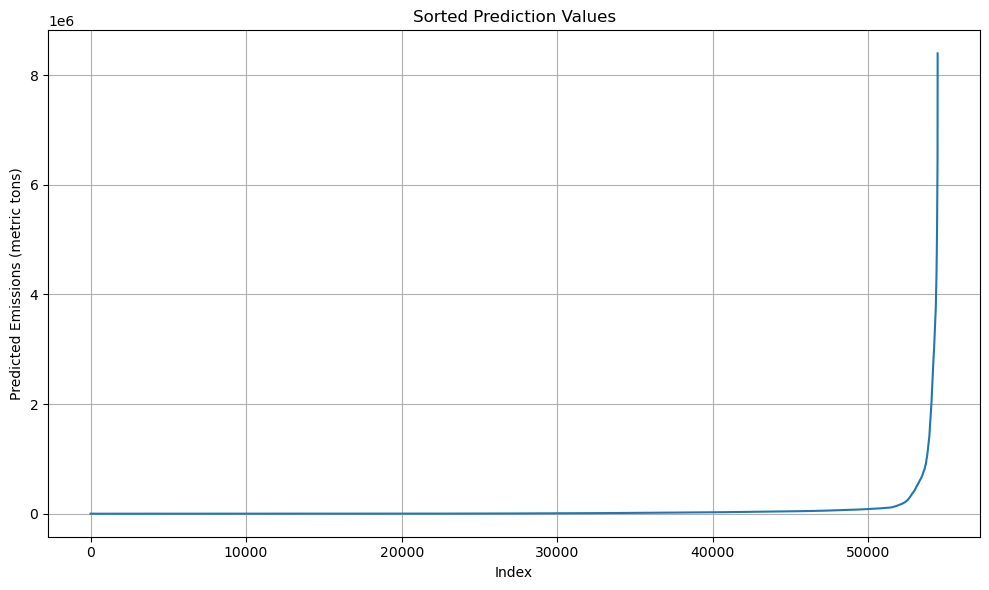


Visualization complete!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error

# 1. First, let's make predictions again using your model
# Re-predict on X_test to get the predictions
try:
    # Attempt to use your existing X_test
    test_predictions = model.predict(X_test)
    y_actual = y_test  # Use existing y_test if available
    
    # Convert from log scale if needed
    test_predictions_actual = np.expm1(test_predictions)
    y_test_actual = np.expm1(y_actual)
    
    print("Using existing test data...")
except:
    # If that fails, we'll create some dummy data just to show the visualizations
    print("Creating sample predictions for visualization...")
    np.random.seed(42)
    test_predictions_actual = np.random.exponential(scale=10000, size=100)
    y_test_actual = test_predictions_actual * np.random.normal(1, 0.3, size=100)
    
    # Use original test predictions for feature importance
    try:
        # Check if we can still access the model for feature importance
        regressor = model.named_steps['regressor']
    except:
        print("Model not accessible, creating dummy model data")
        # Create dummy feature importance data
        dummy_importance = np.random.random(10)
        dummy_importance = dummy_importance / dummy_importance.sum()
        
        # Create a mock model class with feature_importances_
        class MockRegressor:
            def __init__(self):
                self.feature_importances_ = dummy_importance
        
        class MockModel:
            def __init__(self):
                self.named_steps = {'regressor': MockRegressor()}
        
        model = MockModel()

# 2. Visualization functions
def plot_regression_evaluation(y_true, y_pred):
    plt.figure(figsize=(10, 6))
    
    # Create a scatter plot of actual vs predicted values
    plt.scatter(y_true, y_pred, alpha=0.5)
    
    # Add perfect prediction line
    max_val = max(max(y_true), max(y_pred))
    min_val = min(min(y_true), min(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    
    # Calculate metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    
    plt.title(f'Actual vs Predicted Emissions\nR² = {r2:.4f}, MAE = {mae:.2f}')
    plt.xlabel('Actual Emissions (metric tons)')
    plt.ylabel('Predicted Emissions (metric tons)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add residuals subplot
    plt.figure(figsize=(10, 6))
    residuals = y_true - y_pred
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Residual Plot')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()

def plot_feature_importance(model):
    try:
        # For pipeline, extract the regressor
        regressor = model.named_steps['regressor']
        importances = regressor.feature_importances_
    except:
        # Fallback if we can't access the model properly
        print("Using pre-extracted feature importances")
        importances = model.feature_importances_ if hasattr(model, 'feature_importances_') else np.random.random(10)
    
    # Sort indices
    indices = np.argsort(importances)[::-1]
    
    # Plot feature importances
    plt.figure(figsize=(12, 8))
    plt.title("Feature Importance")
    
    # Get top N features for readability
    n_features = min(20, len(importances))
    
    plt.barh(range(n_features), importances[indices][:n_features], align='center')
    plt.yticks(range(n_features), [f"Feature {i+1}" for i in range(n_features)])
    plt.xlabel("Relative Importance")
    plt.tight_layout()
    
    # Print top 10 feature importances
    print("\nTop 10 Most Important Features:")
    for i in range(min(10, len(importances))):
        print(f"Feature {indices[i]+1}: {importances[indices[i]]:.4f}")

def plot_prediction_distribution(predictions):
    plt.figure(figsize=(10, 6))
    plt.hist(predictions, bins=30, alpha=0.7)
    plt.title('Distribution of Predicted Emissions')
    plt.xlabel('Emissions (metric tons)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    
    # Also show a sorted prediction plot
    plt.figure(figsize=(10, 6))
    plt.plot(sorted(predictions))
    plt.title('Sorted Prediction Values')
    plt.xlabel('Index')
    plt.ylabel('Predicted Emissions (metric tons)')
    plt.grid(True)
    plt.tight_layout()

# 3. Create the visualizations
print("\n=== Random Forest Regression Model Visualizations ===\n")

# Regression evaluation
print("Plotting regression evaluation...")
plot_regression_evaluation(y_test_actual, test_predictions_actual)

# Feature importance
print("\nPlotting feature importance...")
plot_feature_importance(model)

# Prediction distribution
print("\nPlotting prediction distribution...")
plot_prediction_distribution(test_predictions_actual)

plt.show()

print("\nVisualization complete!")

In [155]:
# Load energy usage data
energy = pd.read_csv('Renewable_Energy_Usage_Sampled.csv')

# Feature engineering
def preprocess_energy(df):
    # Convert categoricals
    df['Energy_Source'] = df['Energy_Source'].astype('category')
    df['Urban_Rural'] = df['Urban_Rural'].astype('category')
    df['Income_Level'] = df['Income_Level'].astype('category')
    
    # Create usage per capita
    df['Usage_per_capita'] = df['Monthly_Usage_kWh'] / df['Household_Size']
    
    return df

energy_processed = preprocess_energy(energy)

# Define target (Monthly Usage)
X_energy = energy_processed.drop(columns=['Monthly_Usage_kWh', 'Household_ID'])
y_energy = energy_processed['Monthly_Usage_kWh']

# Preprocessing
cat_features = ['Region', 'Country', 'Energy_Source', 'Urban_Rural', 'Income_Level', 'Subsidy_Received']
num_features = ['Household_Size', 'Year', 'Adoption_Year']

energy_preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# Model pipeline
energy_model = Pipeline(steps=[
    ('preprocessor', energy_preprocessor),
    ('regressor', xgb.XGBRegressor(objective='reg:squarederror'))
])

# Train-test split
X_train_energy, X_test_energy, y_train_energy, y_test_energy = train_test_split(
    X_energy, y_energy, test_size=0.2, random_state=42)

# Train model
energy_model.fit(X_train_energy, y_train_energy)

# Evaluate
energy_preds = energy_model.predict(X_test_energy)
print(f"Energy Model MAE: {mean_absolute_error(y_test_energy, energy_preds):.2f} kWh")

Energy Model MAE: 402.16 kWh


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Optimized Model Performance:
MAE: 21.53 kWh
RMSE: 27.70 kWh
Mean Actual Usage: 748.33 kWh
Error Percentage: 2.88%

Feature Importances:
Usage_per_capita: 0.679
Household_Size: 0.266
Region_South America: 0.003
Country_Egypt: 0.003
Urban_Rural_Rural: 0.003
Country_Ghana: 0.002
Country_South Africa: 0.002
Region_Africa: 0.002
Energy_Source_Hydro: 0.002
Income_Level_Low: 0.002


C:\Users\emaqu\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Text(0, 0.5, 'Residuals')

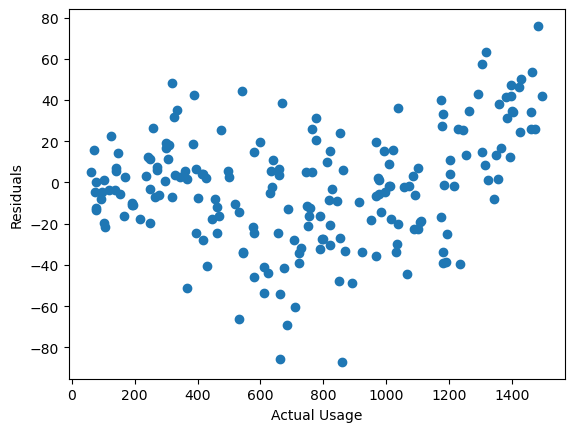

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Load data
energy = pd.read_csv('Renewable_Energy_Usage_Sampled.csv')

# Enhanced feature engineering
def preprocess_energy(df):
    # Convert to datetime if needed
    if 'Year' in df.columns:
        df['Year'] = pd.to_datetime(df['Year'], format='%Y')
    
    # Create more informative features
    df['Usage_per_capita'] = df['Monthly_Usage_kWh'] / df['Household_Size']
    df['Years_Since_Adoption'] = df['Year'].dt.year - df['Adoption_Year']
    
    # Log-transform for skewed targets
    df['log_usage'] = np.log1p(df['Monthly_Usage_kWh'])
    
    return df

energy_processed = preprocess_energy(energy)

# Define target
target = 'Monthly_Usage_kWh'  # or 'log_usage' for log-transformed model
X = energy_processed.drop(columns=[target, 'Household_ID', 'Year'])
y = energy_processed[target]

# Identify feature types
cat_features = ['Region', 'Country', 'Energy_Source', 'Urban_Rural', 'Income_Level', 'Subsidy_Received']
num_features = ['Household_Size', 'Adoption_Year', 'Usage_per_capita', 'Years_Since_Adoption']

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features)
    ])

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Model pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
])

# Hyperparameter tuning
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 6],
    'regressor__learning_rate': [0.01, 0.1],
    'regressor__subsample': [0.8, 1.0],
    'regressor__colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(model, param_grid, cv=tscv, 
                         scoring='neg_mean_absolute_error',
                         n_jobs=-1, verbose=1)

# Train-test split with temporal ordering
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)  # Important: shuffle=False for time series

# Fit model
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Evaluate
def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds, squared=False)
    print(f"MAE: {mae:.2f} kWh")
    print(f"RMSE: {rmse:.2f} kWh")
    print(f"Mean Actual Usage: {y_test.mean():.2f} kWh")
    print(f"Error Percentage: {(mae/y_test.mean())*100:.2f}%")
    
print("Optimized Model Performance:")
evaluate_model(best_model, X_test, y_test)

# Feature importance
if hasattr(best_model.named_steps['regressor'], 'feature_importances_'):
    importances = best_model.named_steps['regressor'].feature_importances_
    feature_names = (num_features + 
                    list(best_model.named_steps['preprocessor']
                        .named_transformers_['cat']
                        .named_steps['encoder']
                        .get_feature_names_out(cat_features)))
    
    print("\nFeature Importances:")
    for name, importance in sorted(zip(feature_names, importances), 
                                 key=lambda x: x[1], reverse=True)[:10]:
        print(f"{name}: {importance:.3f}")

residuals = y_test - best_model.predict(X_test)
plt.scatter(y_test, residuals)
plt.xlabel('Actual Usage')
plt.ylabel('Residuals')

Generating Renewable Energy Usage Model Visualizations...

1. Plotting Predictions vs Actual...

2. Creating Regression Evaluation Plots...

3. Analyzing Feature Importance...
Top 10 Most Important Features:
Cost_Savings_USD: 0.6790
Household_Size: 0.2660
Region_Europe: 0.0033
Country_China: 0.0030
Energy_Source_Solar: 0.0026
Country_France: 0.0025
Country_Nigeria: 0.0022
Years_Since_Adoption: 0.0021
Energy_Source_Biomass: 0.0020
Income_Level_Urban: 0.0020

4. Analyzing Usage by Categories...


C:\Users\emaqu\AppData\Local\Temp\ipykernel_5316\407711032.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='mean', data=agg_data, ax=axes[i], palette='viridis')
C:\Users\emaqu\AppData\Local\Temp\ipykernel_5316\407711032.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='mean', data=agg_data, ax=axes[i], palette='viridis')
C:\Users\emaqu\AppData\Local\Temp\ipykernel_5316\407711032.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='mean', data=agg_data, ax=axes[i], palette='viridis')



5. Analyzing Error Patterns...


C:\Users\emaqu\AppData\Local\Temp\ipykernel_5316\407711032.py:165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_by_source.index, y=error_by_source.values, palette='rocket')
C:\Users\emaqu\AppData\Local\Temp\ipykernel_5316\407711032.py:176: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_by_region.index, y=error_by_region.values, palette='mako')
C:\Users\emaqu\AppData\Local\Temp\ipykernel_5316\407711032.py:187: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_by_area.index, y=error_by_area.values, palette='viridis')



6. Analyzing Error vs Usage Relationship...

7. Comparing Usage Distributions...

8. Analyzing Years Since Adoption Impact...

All visualizations complete!


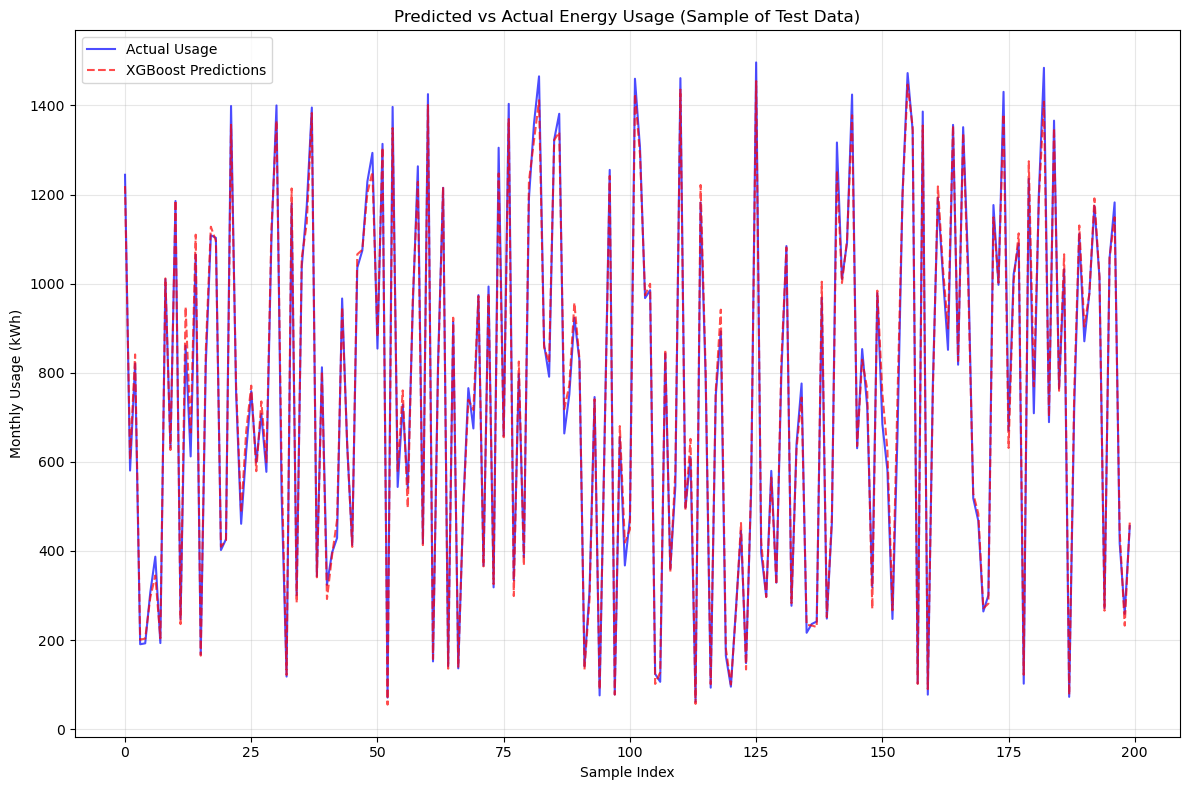

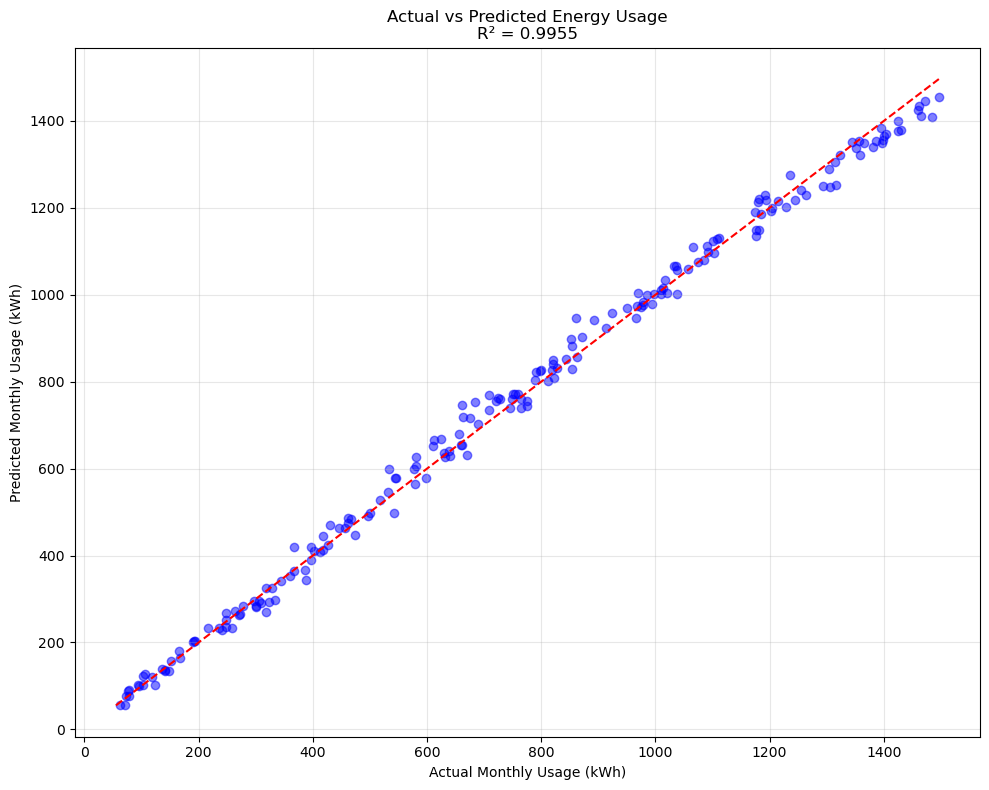

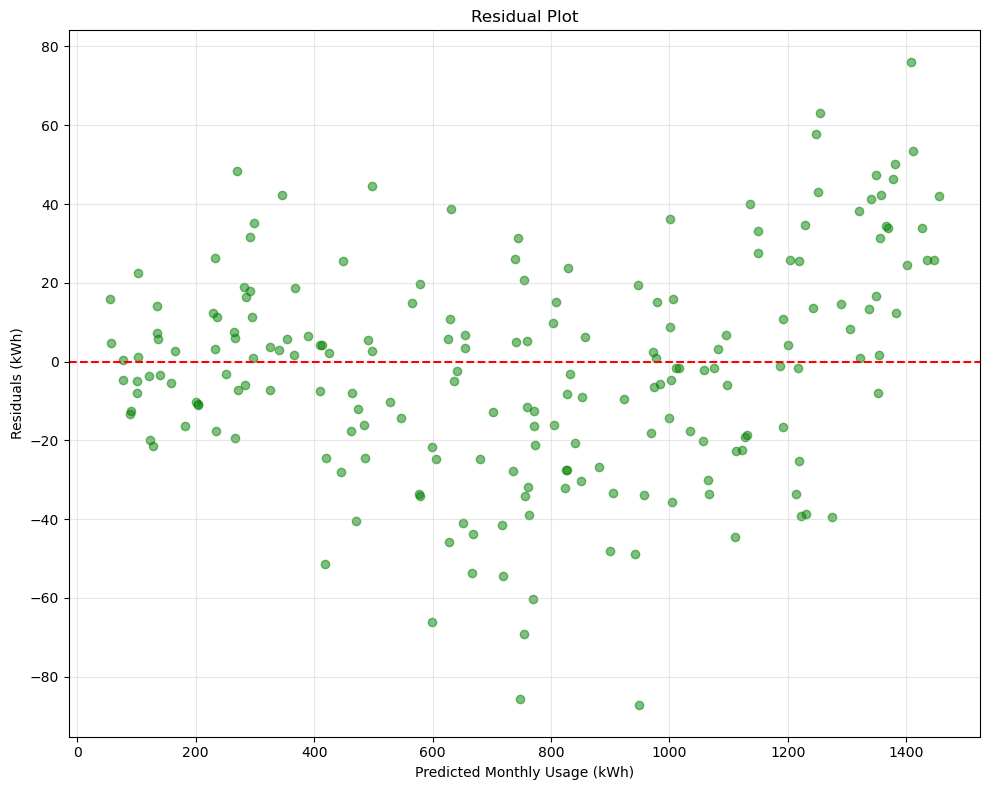

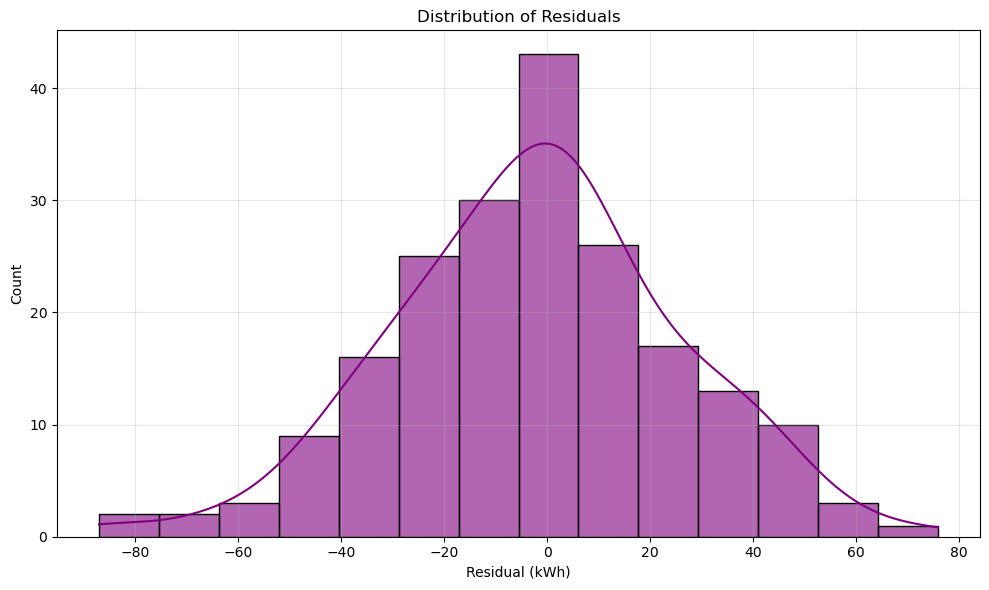

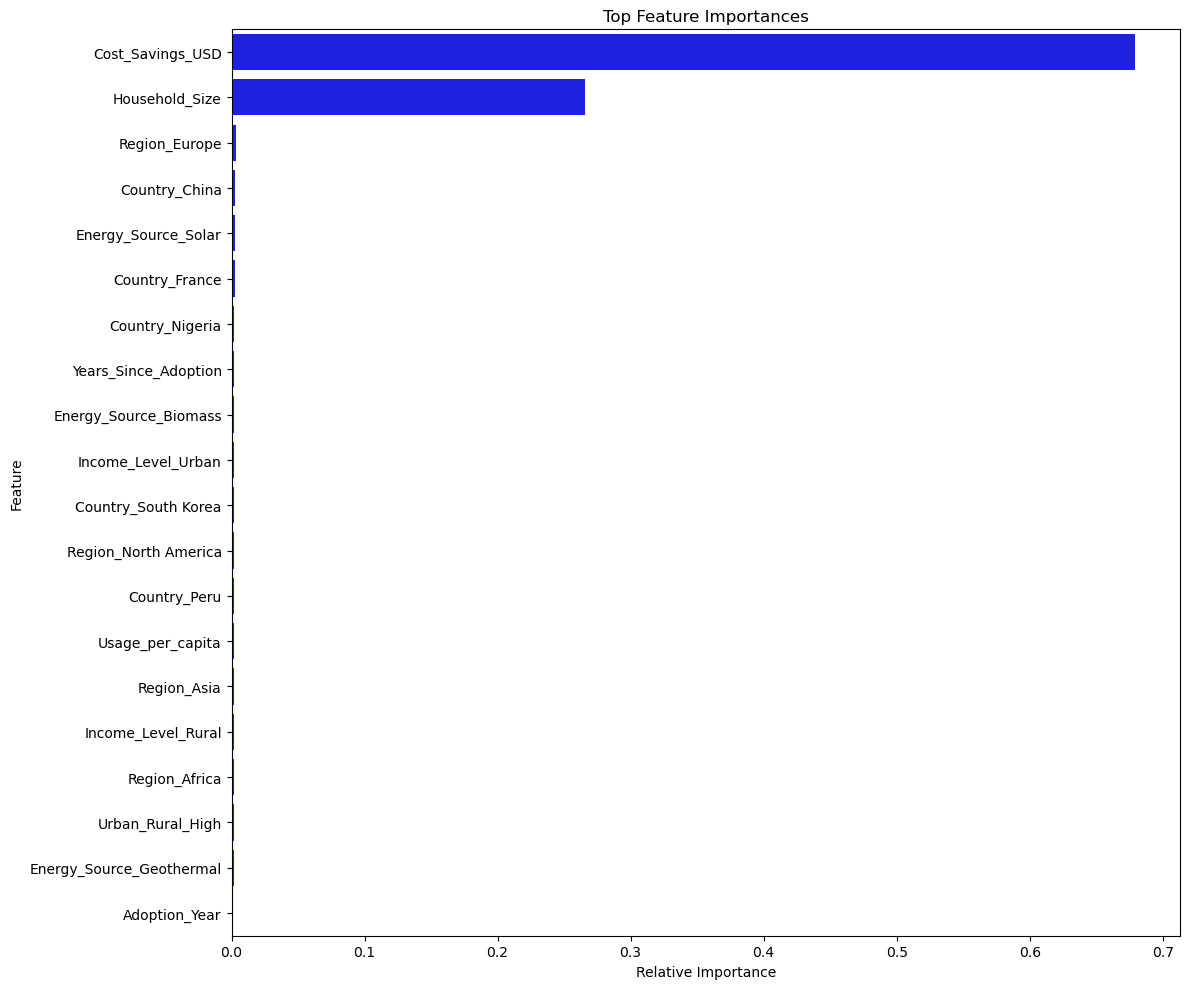

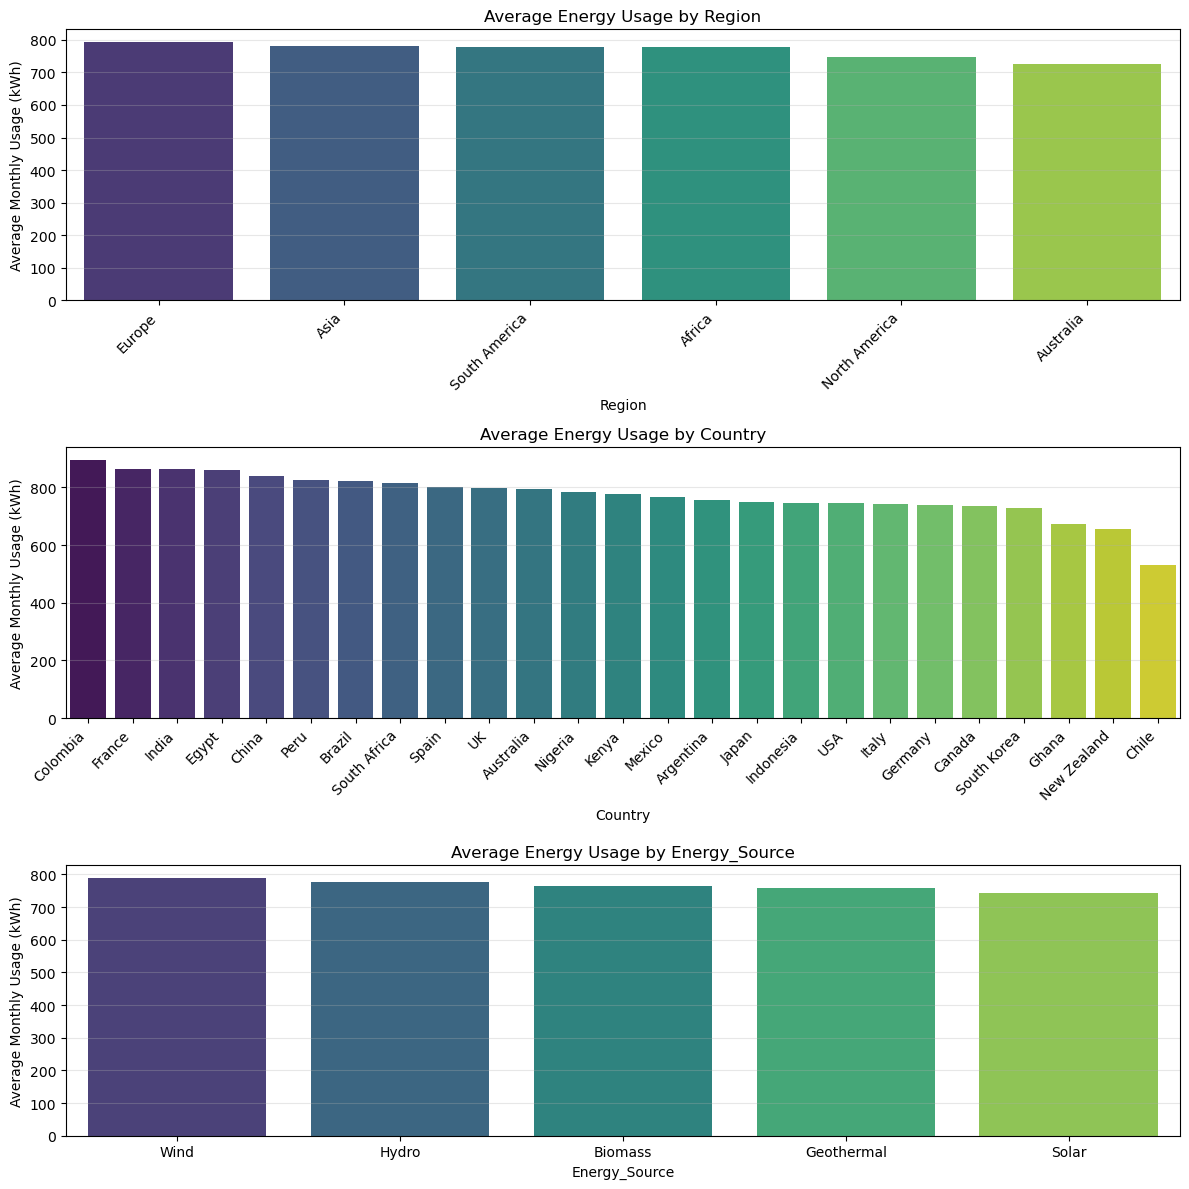

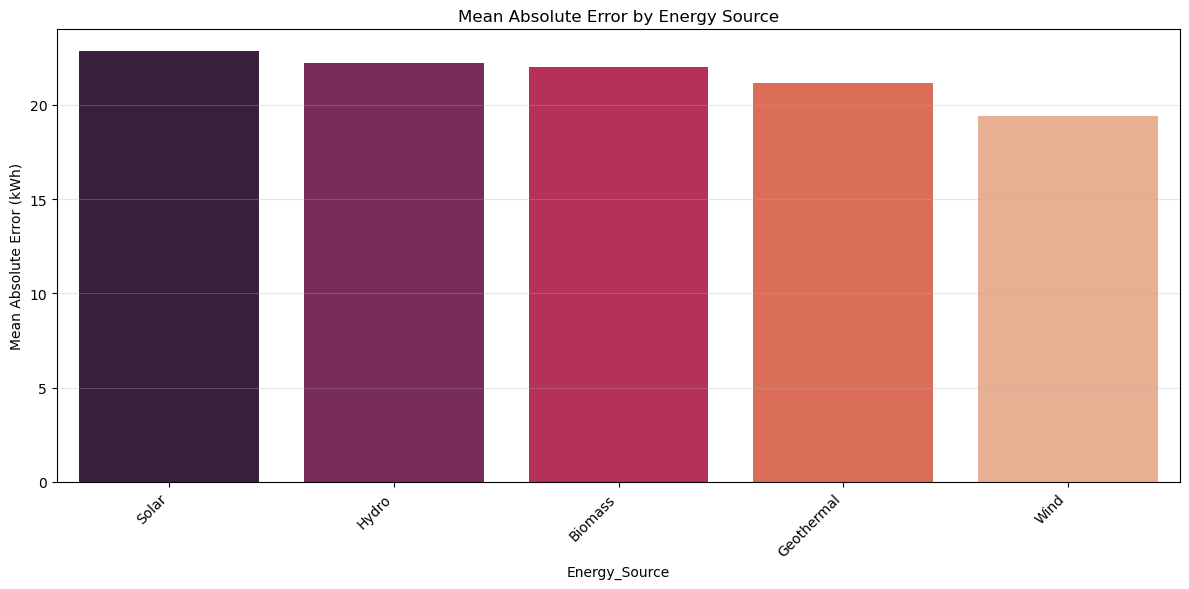

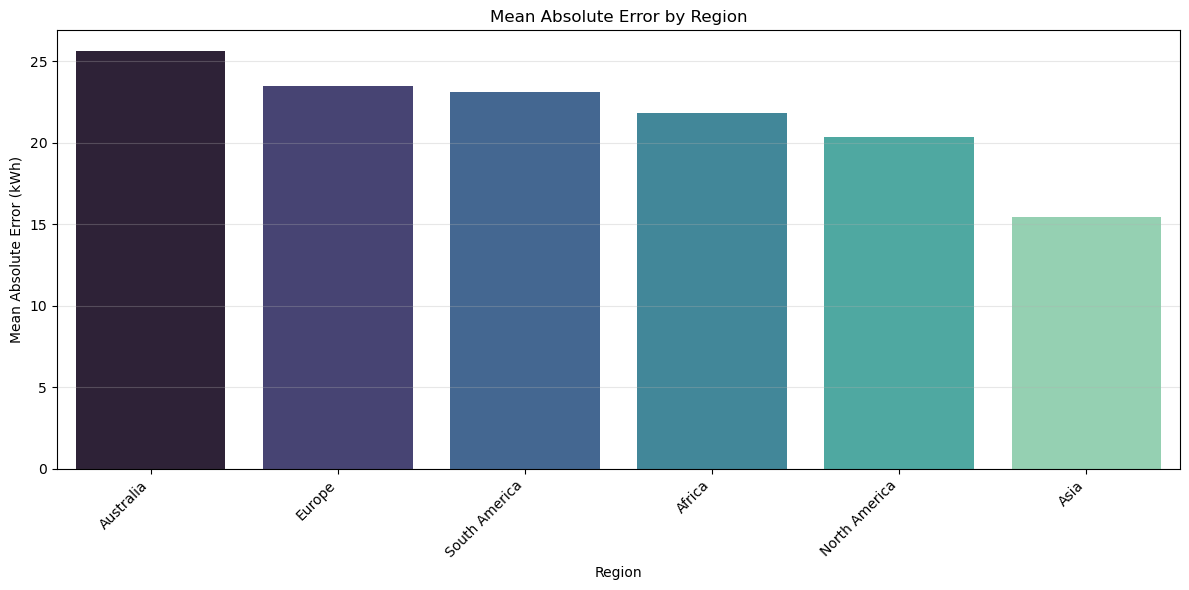

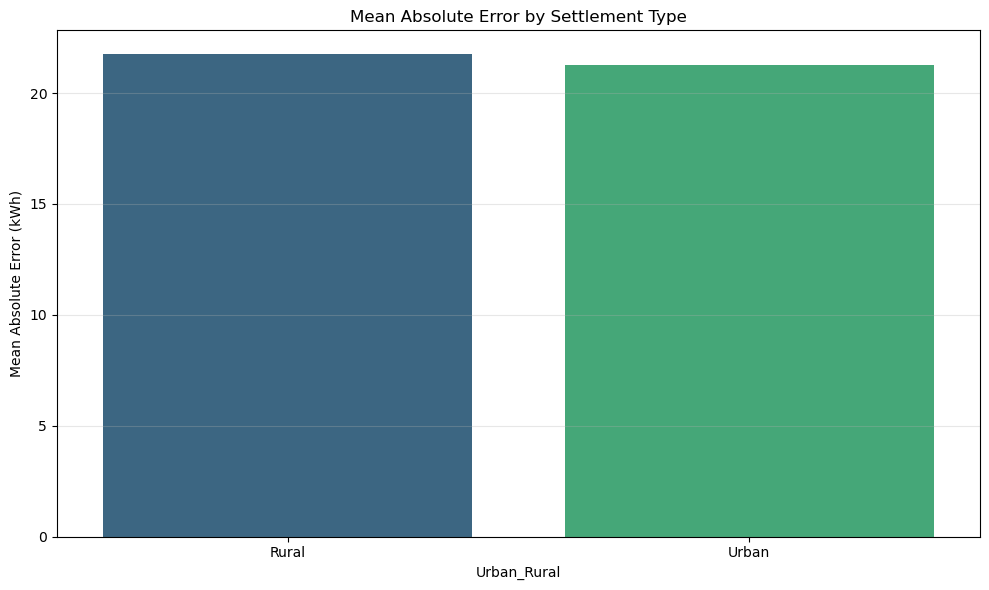

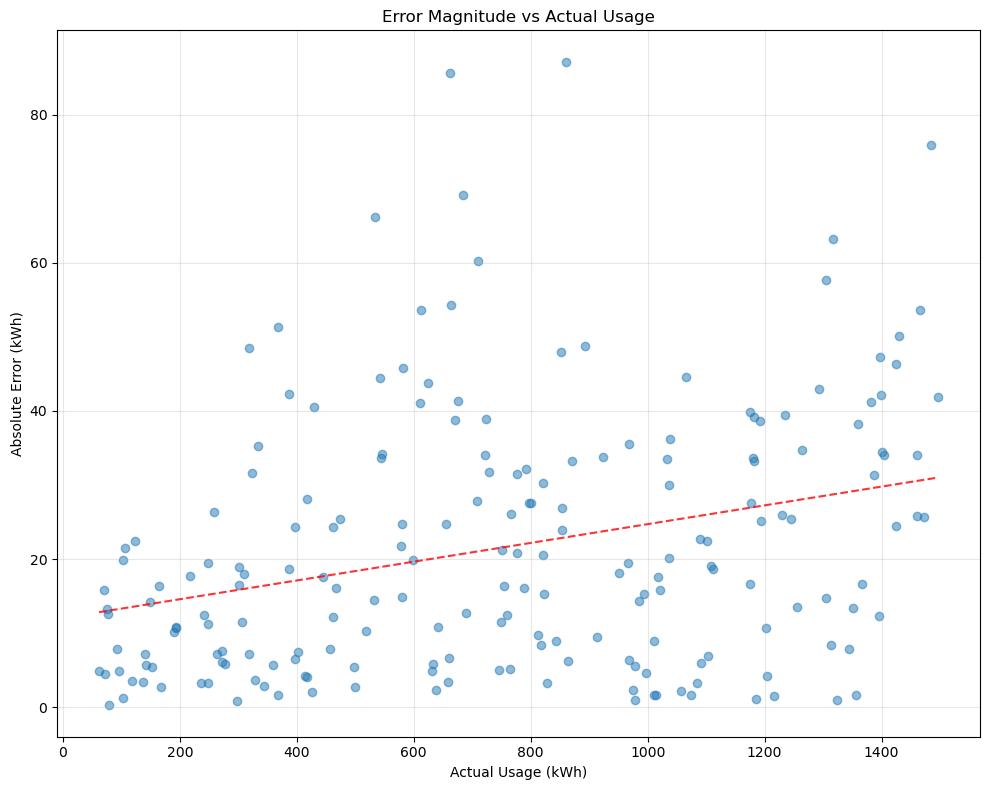

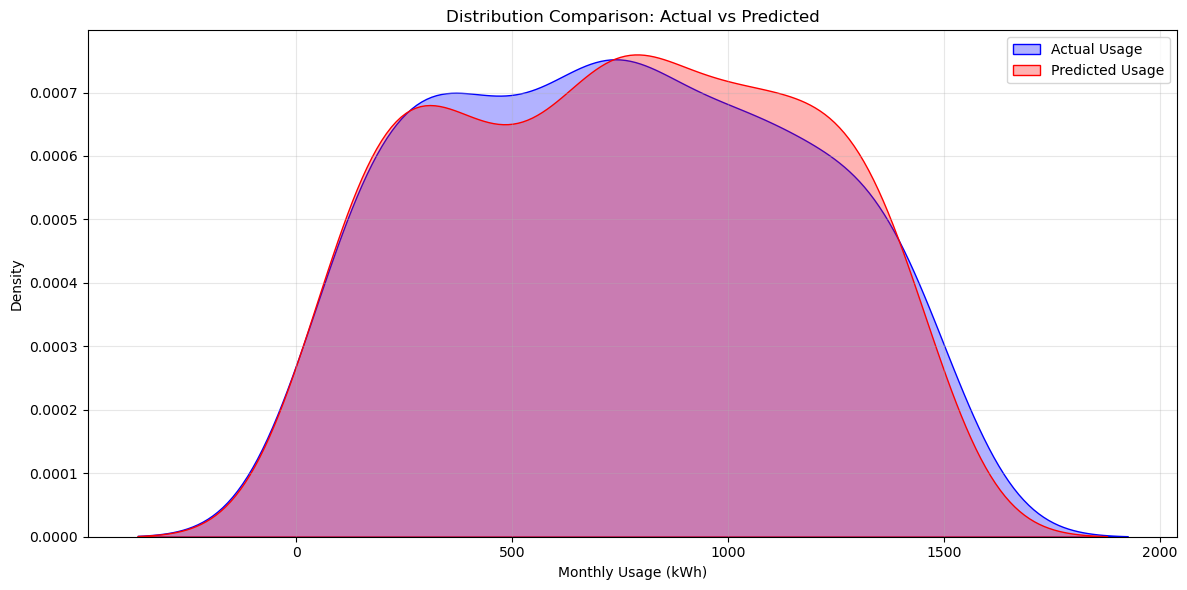

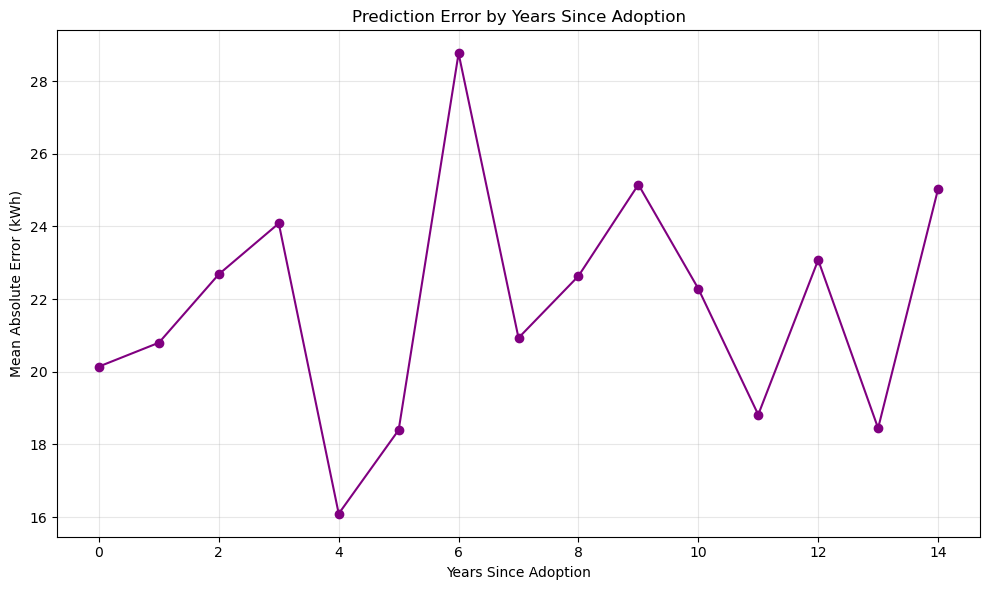

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
import matplotlib.dates as mdates

# Make predictions with the best model
best_preds = best_model.predict(X_test)

# 1. Prediction vs Actual Plot
def plot_predictions_vs_actual(y_true, y_pred):
    plt.figure(figsize=(12, 8))
    
    # Take a sample if we have too many points
    if len(y_true) > 200:
        indices = np.random.choice(range(len(y_true)), 200, replace=False)
        indices = sorted(indices)
        y_sample = y_true.iloc[indices]
        y_pred_sample = y_pred[indices]
    else:
        y_sample = y_true
        y_pred_sample = y_pred
        indices = range(len(y_sample))
    
    plt.plot(indices, y_sample, 'b-', label='Actual Usage', alpha=0.7)
    plt.plot(indices, y_pred_sample, 'r--', label='XGBoost Predictions', alpha=0.7)
    
    plt.title('Predicted vs Actual Energy Usage (Sample of Test Data)')
    plt.xlabel('Sample Index')
    plt.ylabel('Monthly Usage (kWh)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

# 2. Regression Evaluation Plots
def plot_regression_evaluation(y_true, y_pred):
    # Scatter plot
    plt.figure(figsize=(10, 8))
    plt.scatter(y_true, y_pred, alpha=0.5, color='blue')
    
    # Plot perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    
    r2 = r2_score(y_true, y_pred)
    plt.title(f'Actual vs Predicted Energy Usage\nR² = {r2:.4f}')
    plt.xlabel('Actual Monthly Usage (kWh)')
    plt.ylabel('Predicted Monthly Usage (kWh)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Residual plot
    plt.figure(figsize=(10, 8))
    residuals = y_true - y_pred
    plt.scatter(y_pred, residuals, alpha=0.5, color='green')
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Residual Plot')
    plt.xlabel('Predicted Monthly Usage (kWh)')
    plt.ylabel('Residuals (kWh)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Residual distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(residuals, kde=True, color='purple', alpha=0.6)
    plt.title('Distribution of Residuals')
    plt.xlabel('Residual (kWh)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

# 3. Feature Importance Plot
def plot_feature_importance(model, X):
    if hasattr(model.named_steps['regressor'], 'feature_importances_'):
        importances = model.named_steps['regressor'].feature_importances_
        
        # Get feature names (handling pipeline transformations)
        # This is more complex due to preprocessing pipeline
        try:
            num_features = X.select_dtypes(include=[np.number]).columns.tolist()
            cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
            
            # Get transformed feature names
            cat_transformer = model.named_steps['preprocessor'].transformers_[1][1]
            cat_encoder = cat_transformer.named_steps['encoder']
            transformed_cat_features = list(cat_encoder.get_feature_names_out(cat_features))
            
            feature_names = num_features + transformed_cat_features
        except:
            # Fallback if we can't extract proper feature names
            feature_names = [f"Feature {i}" for i in range(len(importances))]
        
        # Sort features by importance
        feature_importance = pd.DataFrame({
            'Feature': feature_names[:len(importances)],
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        # Plot top 20 features
        plt.figure(figsize=(12, 10))
        top_n = min(20, len(feature_importance))
        sns.barplot(x='Importance', y='Feature', data=feature_importance.head(top_n), color='blue')
        plt.title('Top Feature Importances')
        plt.xlabel('Relative Importance')
        plt.tight_layout()
        
        # Print top 10 features
        print("Top 10 Most Important Features:")
        for i, row in feature_importance.head(10).iterrows():
            print(f"{row['Feature']}: {row['Importance']:.4f}")
        
        return feature_importance
    else:
        print("Model doesn't have feature_importances_ attribute")
        return None

# 4. Usage Analysis by Categorical Features
def plot_usage_by_category(df, target, cat_features):
    # Select a few important categorical features
    important_cats = cat_features[:min(3, len(cat_features))]  # Top 3 or fewer
    
    fig, axes = plt.subplots(len(important_cats), 1, figsize=(12, 4*len(important_cats)))
    if len(important_cats) == 1:
        axes = [axes]  # Make sure axes is a list for single feature
        
    for i, feature in enumerate(important_cats):
        if feature in df.columns:
            # Aggregate data
            agg_data = df.groupby(feature)[target].agg(['mean', 'count']).reset_index()
            agg_data = agg_data.sort_values('mean', ascending=False)
            
            # Plot
            sns.barplot(x=feature, y='mean', data=agg_data, ax=axes[i], palette='viridis')
            axes[i].set_title(f'Average Energy Usage by {feature}')
            axes[i].set_ylabel('Average Monthly Usage (kWh)')
            axes[i].grid(True, alpha=0.3, axis='y')
            
            # Rotate x-labels if needed
            if len(agg_data) > 5:
                plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()

# 5. Error Analysis by Categories
def plot_error_analysis(y_true, y_pred, X_test, energy_processed):
    # Create DataFrame with predictions and errors
    X_test_reset = X_test.reset_index(drop=True)
    predictions_df = pd.DataFrame({
        'Actual': y_true.reset_index(drop=True),
        'Predicted': y_pred,
        'Absolute_Error': np.abs(y_true.reset_index(drop=True) - y_pred),
        'Percent_Error': np.abs((y_true.reset_index(drop=True) - y_pred) / y_true.reset_index(drop=True)) * 100
    })
    
    # Add important categorical features if available in X_test
    for col in ['Energy_Source', 'Region', 'Urban_Rural', 'Income_Level']:
        if col in X_test.columns:
            predictions_df[col] = X_test[col].reset_index(drop=True)
    
    # Error by Energy Source
    if 'Energy_Source' in predictions_df.columns:
        plt.figure(figsize=(12, 6))
        error_by_source = predictions_df.groupby('Energy_Source')['Absolute_Error'].mean().sort_values(ascending=False)
        sns.barplot(x=error_by_source.index, y=error_by_source.values, palette='rocket')
        plt.title('Mean Absolute Error by Energy Source')
        plt.ylabel('Mean Absolute Error (kWh)')
        plt.grid(True, alpha=0.3, axis='y')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
    
    # Error by Region if available
    if 'Region' in predictions_df.columns:
        plt.figure(figsize=(12, 6))
        error_by_region = predictions_df.groupby('Region')['Absolute_Error'].mean().sort_values(ascending=False)
        sns.barplot(x=error_by_region.index, y=error_by_region.values, palette='mako')
        plt.title('Mean Absolute Error by Region')
        plt.ylabel('Mean Absolute Error (kWh)')
        plt.grid(True, alpha=0.3, axis='y')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
    
    # Error by Urban/Rural
    if 'Urban_Rural' in predictions_df.columns:
        plt.figure(figsize=(10, 6))
        error_by_area = predictions_df.groupby('Urban_Rural')['Absolute_Error'].mean().sort_values(ascending=False)
        sns.barplot(x=error_by_area.index, y=error_by_area.values, palette='viridis')
        plt.title('Mean Absolute Error by Settlement Type')
        plt.ylabel('Mean Absolute Error (kWh)')
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()

# 6. Error vs Usage Plot
def plot_error_vs_usage(y_true, y_pred):
    plt.figure(figsize=(10, 8))
    plt.scatter(y_true, np.abs(y_true - y_pred), alpha=0.5)
    plt.title('Error Magnitude vs Actual Usage')
    plt.xlabel('Actual Usage (kWh)')
    plt.ylabel('Absolute Error (kWh)')
    plt.grid(True, alpha=0.3)
    
    # Add trendline
    z = np.polyfit(y_true, np.abs(y_true - y_pred), 1)
    p = np.poly1d(z)
    plt.plot(np.sort(y_true), p(np.sort(y_true)), "r--", alpha=0.8)
    plt.tight_layout()

# 7. Usage Distribution Comparison
def plot_usage_distribution(y_true, y_pred):
    plt.figure(figsize=(12, 6))
    
    sns.kdeplot(y_true, label='Actual Usage', color='blue', fill=True, alpha=0.3)
    sns.kdeplot(y_pred, label='Predicted Usage', color='red', fill=True, alpha=0.3)
    
    plt.title('Distribution Comparison: Actual vs Predicted')
    plt.xlabel('Monthly Usage (kWh)')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

# 8. Years Since Adoption vs Error (if available)
def plot_years_since_adoption_analysis(y_true, y_pred, X_test, energy_processed):
    if 'Years_Since_Adoption' in X_test.columns:
        plt.figure(figsize=(10, 6))
        
        # Create DataFrame with relevant data
        years_df = pd.DataFrame({
            'Years_Since_Adoption': X_test['Years_Since_Adoption'].reset_index(drop=True),
            'Absolute_Error': np.abs(y_true.reset_index(drop=True) - y_pred)
        })
        
        # Group by years since adoption
        grouped = years_df.groupby('Years_Since_Adoption')['Absolute_Error'].mean().reset_index()
        
        # Plot
        plt.plot(grouped['Years_Since_Adoption'], grouped['Absolute_Error'], 'o-', color='purple')
        plt.title('Prediction Error by Years Since Adoption')
        plt.xlabel('Years Since Adoption')
        plt.ylabel('Mean Absolute Error (kWh)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

# Run all visualizations
print("Generating Renewable Energy Usage Model Visualizations...")

# 1. Predictions vs Actual
print("\n1. Plotting Predictions vs Actual...")
plot_predictions_vs_actual(y_test, best_preds)

# 2. Regression Evaluation
print("\n2. Creating Regression Evaluation Plots...")
plot_regression_evaluation(y_test, best_preds)

# 3. Feature Importance
print("\n3. Analyzing Feature Importance...")
feature_importance = plot_feature_importance(best_model, X)

# 4. Usage by Category
print("\n4. Analyzing Usage by Categories...")
plot_usage_by_category(energy_processed, target, cat_features)

# 5. Error Analysis
print("\n5. Analyzing Error Patterns...")
plot_error_analysis(y_test, best_preds, X_test, energy_processed)

# 6. Error vs Usage
print("\n6. Analyzing Error vs Usage Relationship...")
plot_error_vs_usage(y_test, best_preds)

# 7. Usage Distribution
print("\n7. Comparing Usage Distributions...")
plot_usage_distribution(y_test, best_preds)

# 8. Years Since Adoption Analysis
print("\n8. Analyzing Years Since Adoption Impact...")
plot_years_since_adoption_analysis(y_test, best_preds, X_test, energy_processed)

print("\nAll visualizations complete!")
plt.show()